In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy import stats

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_excel("proteins_dataset.xlsx")

df.head(10)

,ID_Proteína,Sequences,Massa_Molecular,Isoeletric_point,Hidrofobicidade,Carga_Total,Polar,Apolar,Comprimento_Sequence,Class
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptora
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Estrutural
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzima
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transporte
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Outras
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptora
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Outras
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzima
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Estrutural
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzima


In [8]:
df.rename(columns={
    "ID_Proteína": "Protein_ID",
    "Sequences": "Protein_Sequence",
    "Massa_Molecular": "Molecular_Weight",
    "Isoeletric_point": "Isoelectric_Point",
    "Hidrofobicidade": "Hydrophobicity",
    "Carga_Total": "Total_Charge",
    "Polar": "Polar_Content",
    "Apolar": "Apolar_Content",
    "Comprimento_Sequence": "Sequence_Length",
    "Class": "Protein_Class"
}, inplace=True)

df.head(10)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptora
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Estrutural
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzima
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transporte
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Outras
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptora
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Outras
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzima
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Estrutural
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzima


In [9]:
df["Protein_Class"] = df["Protein_Class"].replace({
    "Receptora": "Receptor",
    "Estrutural": "Structural",
    "Enzima": "Enzyme",
    "Transporte": "Transport",
    "Outras": "Others"
})

df["Protein_Class"].value_counts()

Protein_Class
Others        12216
Structural    11991
Transport     11989
Enzyme        11954
Receptor      11850
Name: count, dtype: int64

In [10]:
df.shape

(60000, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Protein_ID         60000 non-null  object 
 1   Protein_Sequence   60000 non-null  object 
 2   Molecular_Weight   60000 non-null  float64
 3   Isoelectric_Point  60000 non-null  float64
 4   Hydrophobicity     60000 non-null  float64
 5   Total_Charge       60000 non-null  int64  
 6   Polar_Content      60000 non-null  float64
 7   Apolar_Content     60000 non-null  float64
 8   Sequence_Length    60000 non-null  int64  
 9   Protein_Class      60000 non-null  object 
dtypes: float64(5), int64(2), object(3)
memory usage: 4.6+ MB


In [12]:
df.describe()

,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,20798.002743,7.259727,0.149968,8.727517,0.199930,0.400025,174.775683
std,8611.766490,1.447584,0.027094,7.503895,0.033709,0.041577,72.330865
min,5407.315100,4.050028,0.000000,-18.000000,0.018182,0.173077,50.000000
25%,13353.876800,6.051557,0.133136,3.000000,0.178571,0.373984,112.000000
50%,20784.058050,7.155000,0.150000,8.000000,0.199301,0.400000,175.000000
75%,28221.612275,8.585916,0.166667,13.000000,0.220859,0.425743,237.000000
max,37097.077600,11.785610,0.289474,52.000000,0.400000,0.640000,300.000000


In [13]:
df.columns

Index(['Protein_ID', 'Protein_Sequence', 'Molecular_Weight',
       'Isoelectric_Point', 'Hydrophobicity', 'Total_Charge', 'Polar_Content',
       'Apolar_Content', 'Sequence_Length', 'Protein_Class'],
      dtype='object')

In [14]:
df.isnull().sum()

Protein_ID           0
Protein_Sequence     0
Molecular_Weight     0
Isoelectric_Point    0
Hydrophobicity       0
Total_Charge         0
Polar_Content        0
Apolar_Content       0
Sequence_Length      0
Protein_Class        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["Protein_Class"].value_counts()

Protein_Class
Others        12216
Structural    11991
Transport     11989
Enzyme        11954
Receptor      11850
Name: count, dtype: int64

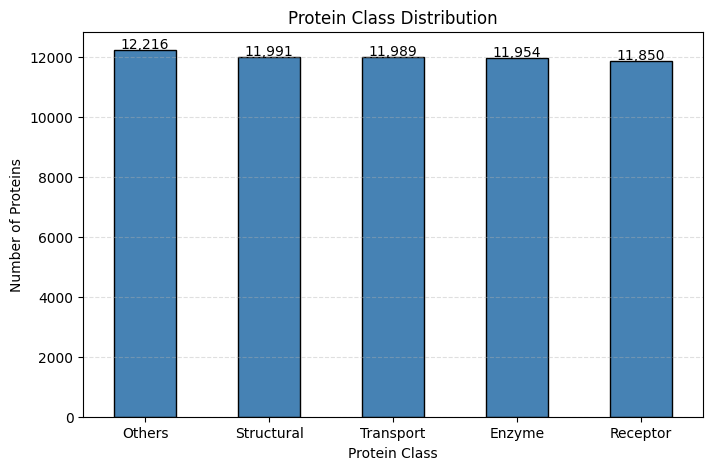

In [19]:
protein_counts = df["Protein_Class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = protein_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Protein Class Distribution")
plt.xlabel("Protein Class")
plt.ylabel("Number of Proteins")
plt.xticks(rotation=0)

for i, value in enumerate(protein_counts):
    plt.text(i, value + 40, f"{value:,}", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

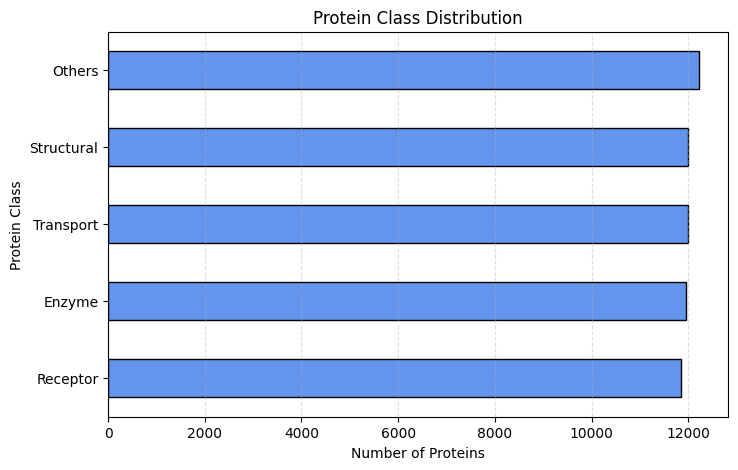

In [20]:
protein_counts = df["Protein_Class"].value_counts().sort_values()

plt.figure(figsize=(8,5))

protein_counts.plot(
    kind="barh",
    color="cornflowerblue",
    edgecolor="black"
)

plt.title("Protein Class Distribution")
plt.xlabel("Number of Proteins")
plt.ylabel("Protein Class")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

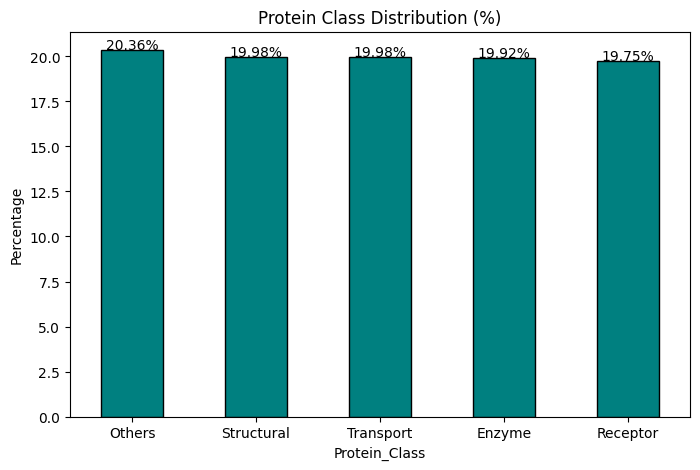

In [21]:
protein_percent = (
    df["Protein_Class"]
      .value_counts(normalize=True)
      .mul(100)
)

plt.figure(figsize=(8,5))

ax = protein_percent.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Protein Class Distribution (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

for i, value in enumerate(protein_percent):
    plt.text(i, value + 0.05, f"{value:.2f}%", ha="center")

plt.show()

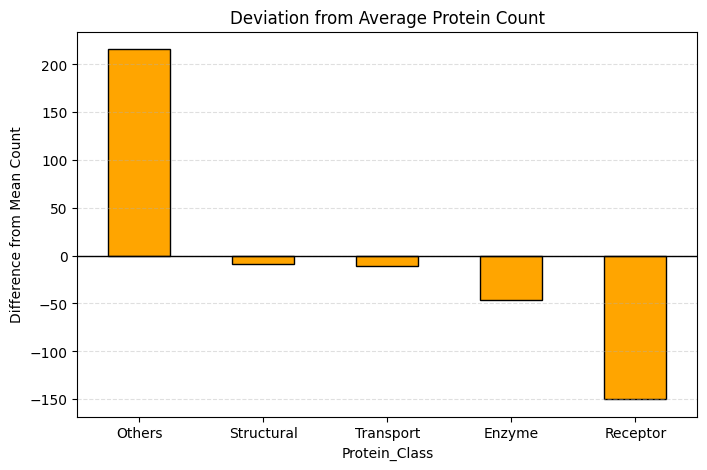

In [22]:
protein_counts = df["Protein_Class"].value_counts()

difference = protein_counts - protein_counts.mean()

plt.figure(figsize=(8,5))

difference.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Deviation from Average Protein Count")
plt.ylabel("Difference from Mean Count")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

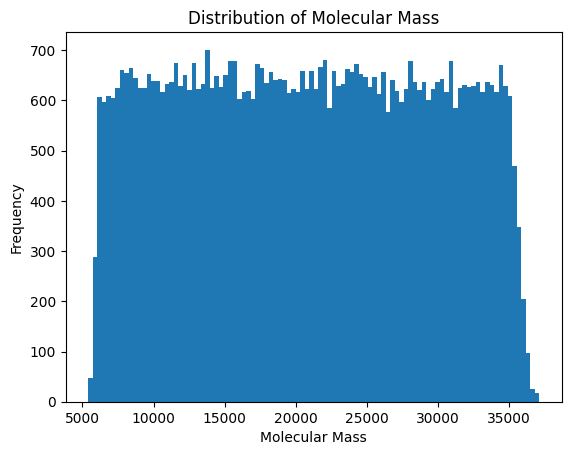

In [26]:
plt.hist(df["Molecular_Weight"], bins=100)

plt.xlabel("Molecular Mass")
plt.ylabel("Frequency")
plt.title("Distribution of Molecular Mass")

plt.show()

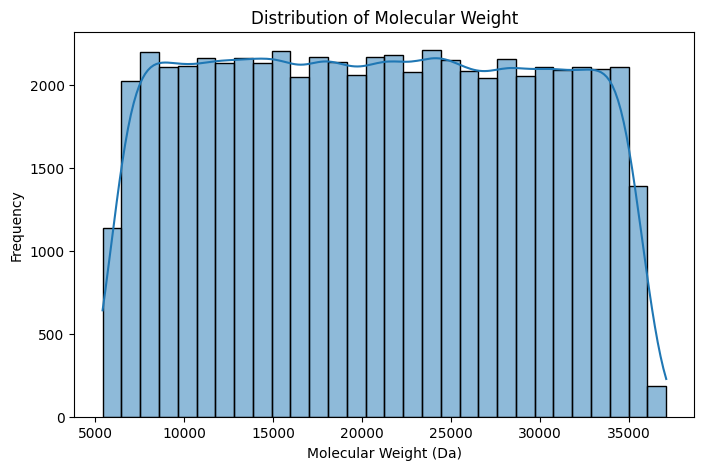

In [23]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Molecular_Weight",
    bins=30,
    kde=True
)

plt.title("Distribution of Molecular Weight")
plt.xlabel("Molecular Weight (Da)")
plt.ylabel("Frequency")

plt.show()

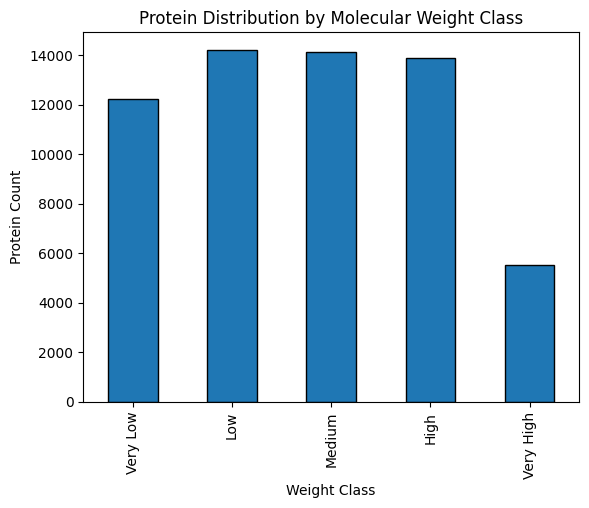

In [24]:
bins = [5000, 12000, 19000, 26000, 33000, 40000]

labels = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

df["Weight_Class"] = pd.cut(
    df["Molecular_Weight"],
    bins=bins,
    labels=labels
)

df["Weight_Class"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Weight Class")
plt.ylabel("Protein Count")
plt.title("Protein Distribution by Molecular Weight Class")

plt.show()

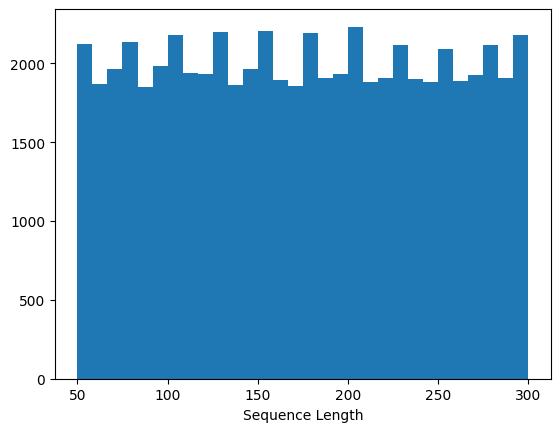

In [15]:
plt.hist(df["Sequence_Length"], bins=30)

plt.xlabel("Sequence Length")

plt.show()

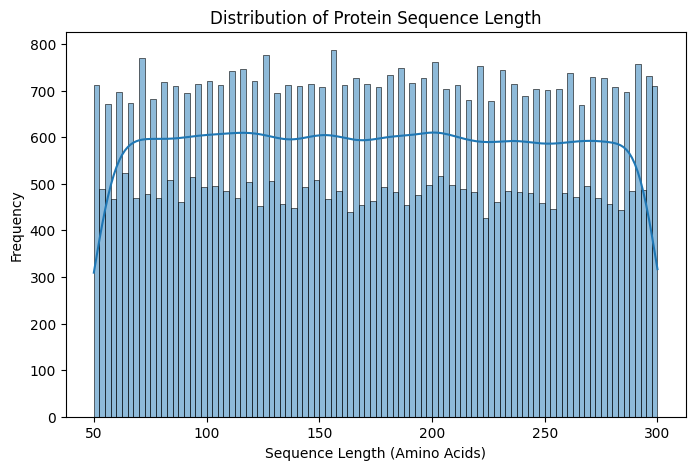

In [27]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Sequence_Length",
    bins=100,
    kde=True
)

plt.xlabel("Sequence Length (Amino Acids)")
plt.ylabel("Frequency")
plt.title("Distribution of Protein Sequence Length")

plt.show()

In [29]:
df.groupby("Protein_Class")["Molecular_Weight"].mean()

Protein_Class
Enzyme        20858.182339
Others        20785.990127
Receptor      20821.137854
Structural    20719.469953
Transport     20805.917902
Name: Molecular_Weight, dtype: float64

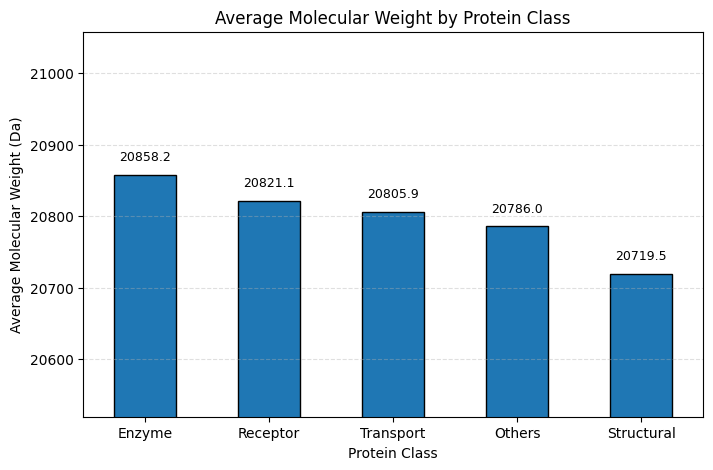

In [31]:
mean_weight = (
    df.groupby("Protein_Class")["Molecular_Weight"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = mean_weight.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Molecular Weight by Protein Class")
plt.xlabel("Protein Class")
plt.ylabel("Average Molecular Weight (Da)")
plt.xticks(rotation=0)

# Zoom the y-axis around the data
plt.ylim(mean_weight.min()-200, mean_weight.max()+200)

# Add value labels
for i, v in enumerate(mean_weight):
    plt.text(i, v+20, f"{v:.1f}", ha="center", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

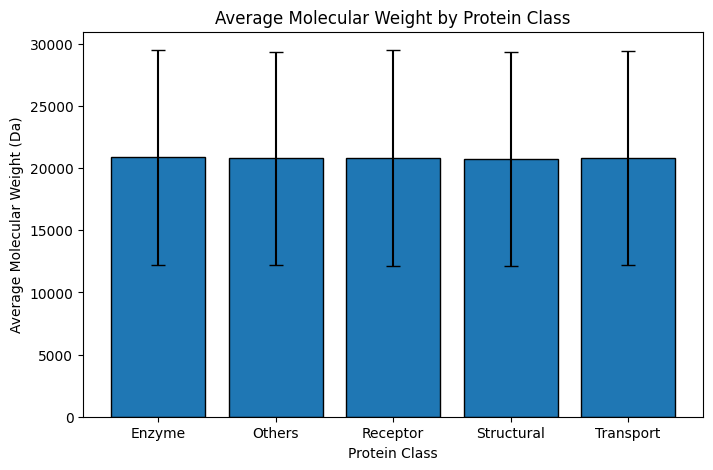

In [32]:
summary = df.groupby("Protein_Class")["Molecular_Weight"].agg(["mean", "std"])

plt.figure(figsize=(8,5))

plt.bar(
    summary.index,
    summary["mean"],
    yerr=summary["std"],
    capsize=5,
    edgecolor="black"
)

plt.title("Average Molecular Weight by Protein Class")
plt.xlabel("Protein Class")
plt.ylabel("Average Molecular Weight (Da)")
plt.xticks(rotation=0)

plt.show()

In [33]:
df.groupby("Protein_Class")["Hydrophobicity"].mean()

Protein_Class
Enzyme        0.149869
Others        0.149966
Receptor      0.150048
Structural    0.150322
Transport     0.149638
Name: Hydrophobicity, dtype: float64

In [34]:
df.groupby("Protein_Class")["Total_Charge"].mean()

Protein_Class
Enzyme        8.709553
Others        8.723232
Receptor      8.857722
Structural    8.670169
Transport     8.678455
Name: Total_Charge, dtype: float64

In [35]:
numeric = df.select_dtypes(include=np.number)
numeric

,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length
0,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209
1,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179
2,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149
3,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98
4,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188
...,...,...,...,...,...,...,...
59995,17576.9275,8.833732,0.143333,12,0.253333,0.346667,150
59996,14658.6439,6.765568,0.179167,7,0.166667,0.458333,120
59997,9412.4561,5.814709,0.086420,3,0.234568,0.296296,81
59998,28956.5694,5.895420,0.162000,4,0.224000,0.420000,250


In [36]:
corr = numeric.corr()
corr

,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length
Molecular_Weight,1.000000,0.053864,0.010183,0.491634,-0.011204,0.011921,0.998940
Isoelectric_Point,0.053864,1.000000,0.318418,0.764733,0.001642,-0.015790,0.046997
Hydrophobicity,0.010183,0.318418,1.000000,0.208131,-0.235442,0.892090,0.003118
Total_Charge,0.491634,0.764733,0.208131,1.000000,-0.037812,-0.065997,0.484299
Polar_Content,-0.011204,0.001642,-0.235442,-0.037812,1.000000,-0.409765,-0.003443
Apolar_Content,0.011921,-0.015790,0.892090,-0.065997,-0.409765,1.000000,0.001836
Sequence_Length,0.998940,0.046997,0.003118,0.484299,-0.003443,0.001836,1.000000


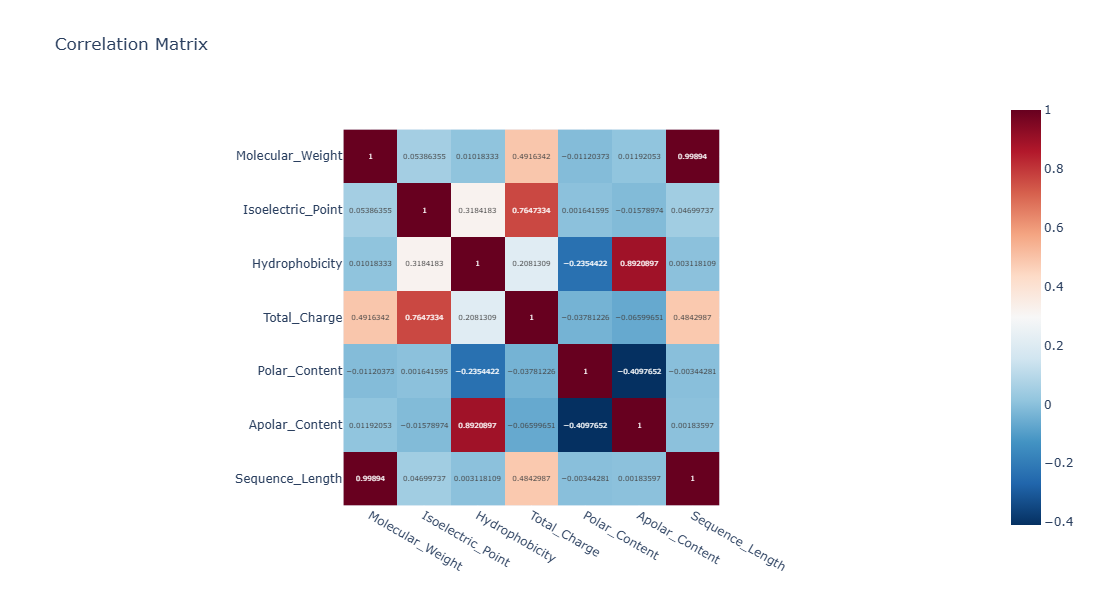

In [37]:
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Matrix",
    width=1200,
    height=600
)

fig.show()

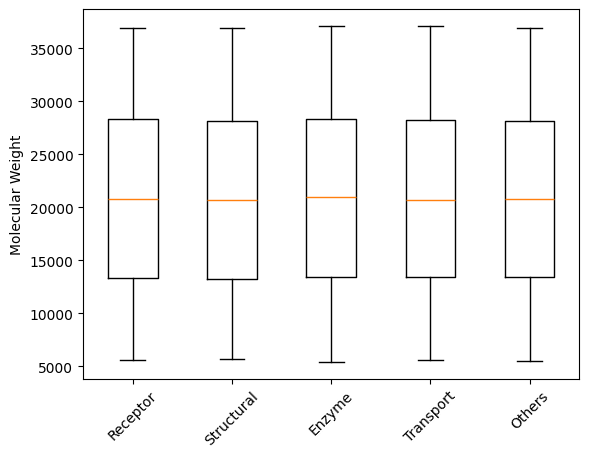

In [38]:
classes=df["Protein_Class"].unique()

data=[]

for c in classes:
    data.append(
        df[df["Protein_Class"]==c]["Molecular_Weight"]
    )

plt.boxplot(data, tick_labels=classes)

plt.xticks(rotation=45)

plt.ylabel("Molecular Weight")

plt.show()

In [39]:
###### Largest proteins

df.nlargest(10, "Molecular_Weight")[["Protein_ID","Molecular_Weight"]]

,Protein_ID,Molecular_Weight
24405,P24406,37097.0776
37476,P37477,37066.7300
44817,P44818,36913.5579
32411,P32412,36909.8286
20742,P20743,36900.0629
39684,P39685,36878.5251
22056,P22057,36877.9766
15664,P15665,36872.5199
19868,P19869,36866.0685
59854,P59855,36855.9305


In [40]:
######## Longest proteins

df.nlargest(10,"Sequence_Length")

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,Weight_Class
87,P00088,SKCDAYRTEGWLYTWTASGLTQSCKIEMEEVWDKFMRLYHVVWHRA...,36090.9253,7.461107,0.160000,13,0.180000,0.416667,300,Structural,Very High
150,P00151,QPSMGIIKNDTMTPQACREFGTNKKQHTCLFWIGIYHHRTIMGSGT...,35411.8656,8.619568,0.118333,22,0.256667,0.330000,300,Transport,Very High
241,P00242,LQPTDKMFKDYQRMVSRGTSIAGWDMNNRRKQEKQFSHIMYIMWSM...,36166.6746,9.511424,0.175000,30,0.223333,0.420000,300,Enzyme,Very High
413,P00414,CMWVLQATNQHAAVGKATKPYTEDSHHNYDNKNVEHSDLNEPRCSN...,35067.6175,6.513373,0.153333,10,0.220000,0.413333,300,Transport,Very High
545,P00546,HCADSFRVHHPCRQFWHVYAEPLPWCWHQFTPIWSCCEHMWYNWET...,36343.2645,7.283485,0.158333,18,0.196667,0.403333,300,Structural,Very High
1019,P01020,LEFMGQMVNKYVRFIYTNKEDNQIIWEESMCPEFHECYRMGIFRTL...,35223.6089,5.401034,0.128333,0,0.216667,0.373333,300,Transport,Very High
1096,P01097,PMYFIQVIYWPLNANTMWHYDMNHFQYWIASENMTIYSNFIMVNCY...,36610.7078,7.769742,0.155000,15,0.173333,0.416667,300,Receptor,Very High
1216,P01217,RVLIFIPIINWEDSFCNKQDPEEAQLQLQHQANCLMRHLKWWSNHF...,36007.7580,6.267374,0.156667,7,0.230000,0.413333,300,Transport,Very High
1902,P01903,YWYANLPNHCEHLLQDVQNMDIAVRPWTAHNDNVNIHYWSHPKIFH...,36547.4628,7.589449,0.173333,22,0.200000,0.423333,300,Structural,Very High
2193,P02194,LLRDEWLVGLDTIQYYDPWRPYQENEPFHCLARPHASRHFWEVWES...,36524.0237,7.356182,0.120000,19,0.196667,0.353333,300,Others,Very High


In [41]:
####### Most Hydrophobic

df.nlargest(10,"Hydrophobicity")

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,Weight_Class
23064,P23065,VMHACQHAKYVILIYWVLSWGLVWDWMSSLSFSMDQYRKLWIHQFY...,7051.1783,8.104079,0.289474,4,0.192982,0.614035,57,Enzyme,Very Low
25280,P25281,ILAKFWYDAMKHIIFCPVVRNAGQCKYGKYYIVCCLNYFFLWHNYY...,11061.9478,9.012954,0.282609,8,0.097826,0.597826,92,Enzyme,Very Low
49480,P49481,HPTAKKRKLKLPWMCLAMMLINMLYLYGCLWGITHITCCLVYAVKT...,7138.8426,9.808558,0.275000,10,0.150000,0.550000,60,Transport,Very Low
17904,P17905,GHFLMVYHMFGWHQAPNVIRGIVWAFARYWWCMAPGPYRDYLWMSQ...,6370.4636,9.511810,0.274510,7,0.078431,0.568627,51,Receptor,Very Low
19096,P19097,TYNMRAAPQLKMGIAWMWAQILHWIWHGRDLPPHWLLFSIREIFAV...,7673.0417,8.206003,0.274194,5,0.096774,0.612903,62,Others,Very Low
14017,P14018,VLVGKYCPQWSYAFAFLLSMSESQADQAIMRFHLHKAYMQHLAFSW...,6245.2857,8.154364,0.273585,6,0.169811,0.584906,53,Others,Very Low
13720,P13721,FWMMARRKPYDPRMVVYFMYAYRNCYVVPHWGNAWNIIMGRNTVLP...,6889.1504,9.651707,0.272727,5,0.109091,0.581818,55,Others,Very Low
22099,P22100,STWINIVLYYIWTCIVANFYYAGYSQYAMSFYMPQGNNLYMINLTN...,6886.8581,7.834408,0.271930,2,0.298246,0.561404,57,Structural,Very Low
50809,P50810,LYNQLYWYFMRPIANSNGHCRESFIVRWLMPYVITYSAWDLVAEYW...,9322.7247,9.170515,0.266667,4,0.186667,0.586667,75,Receptor,Very Low
40003,P40004,QWVCQICFRRYFLQLAHYHYLMKYMFLARAWWSFMMTFQQMCHAIY...,7900.3746,9.783287,0.266129,11,0.161290,0.548387,62,Receptor,Very Low


In [42]:
####### Highest Charge

df.nlargest(10,"Total_Charge")

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,Weight_Class
19089,P19090,RQAIHWNSTEFRIEHPVCIMAQMCRHAPCYIMGRFYTLHYSRMFSC...,34783.0505,10.024334,0.180702,52,0.221053,0.403509,285,Transport,Very High
41686,P41687,CMCQDIRFCPKWRGKRIIWICNKWPVYAGHWTNHRCQKIKQARPQP...,34612.3437,9.840599,0.172474,44,0.184669,0.390244,287,Enzyme,Very High
46768,P46769,EINRQRQRKSMQPQWRQFCFMSGFLFCPGCNGKQTPYQWPNKLRVH...,35947.4082,9.600390,0.146048,42,0.202749,0.353952,291,Transport,Very High
4949,P04950,ECDYSVEGGVCSPTRDIMQIAQPNLWDANAMMMFRQGMAIHEYCTH...,31698.5034,9.765751,0.161710,41,0.174721,0.379182,269,Transport,High
9536,P09537,CKRPTPMGEARKFIEECLYEKRLSSLKHEHGMRIRLLSRTPAMYNN...,35170.9530,9.495436,0.136364,41,0.212121,0.350168,297,Enzyme,Very High
31986,P31987,RSWQWYHPPCQSCMQNYCGMGPLPTTMRRCSCPHKRDKNMYYWGIS...,32826.6120,9.505428,0.143636,41,0.210909,0.338182,275,Structural,High
33409,P33410,NMALGKCIYFAGIGHNPKIPYHSGPSCRLKHIMGEEGDKTGFECNQ...,34895.6306,9.560355,0.141379,41,0.186207,0.358621,290,Receptor,Very High
37393,P37394,CPNHEFRQHQRSAPRWEIYVHYPSMPKRTSAFRTWVGHNLVPAKLM...,34509.2257,9.767492,0.161512,41,0.237113,0.381443,291,Others,Very High
52376,P52377,QWKKYHTLIQINKKTFHRPAKSCVVCFWWRKFWNRTRWDKHHMMWC...,31557.8001,9.867547,0.200758,41,0.196970,0.439394,264,Others,High
56831,P56832,SCFLSMAEWPDTYQRSAGLMQVAFFMVWIASDRIIYKRQCHMMFTY...,34935.2437,9.701283,0.170175,41,0.189474,0.403509,285,Others,Very High


In [43]:
print("Mean of The Table:", numeric.mean())
print("Median of The Table:", numeric.median())
print("Standard deviation of The Table:", numeric.std())
print("Skewness of The Table:", numeric.skew())
print("Kurtosis of The Table:", numeric.kurt())

Mean of The Table: Molecular_Weight     20798.002743
Isoelectric_Point        7.259727
Hydrophobicity           0.149968
Total_Charge             8.727517
Polar_Content            0.199930
Apolar_Content           0.400025
Sequence_Length        174.775683
dtype: float64
Median of The Table: Molecular_Weight     20784.058050
Isoelectric_Point        7.155000
Hydrophobicity           0.150000
Total_Charge             8.000000
Polar_Content            0.199301
Apolar_Content           0.400000
Sequence_Length        175.000000
dtype: float64
Standard deviation of The Table: Molecular_Weight     8611.766490
Isoelectric_Point       1.447584
Hydrophobicity          0.027094
Total_Charge            7.503895
Polar_Content           0.033709
Apolar_Content          0.041577
Sequence_Length        72.330865
dtype: float64
Skewness of The Table: Molecular_Weight     0.011919
Isoelectric_Point   -0.032238
Hydrophobicity      -0.071476
Total_Charge         0.466464
Polar_Content        0.150269
Ap

In [44]:
hydrophobic = {'I', 'V', 'L', 'F', 'C', 'M', 'A'}
hydrophilic = {'Y', 'P', 'H', 'E', 'Q', 'D', 'N', 'K', 'R'}
polar = {'S', 'T', 'N', 'Q'}
apolar = {'A', 'V', 'L', 'I', 'P', 'F', 'M', 'W', 'G', 'C'}
basic = {'H', 'K', 'R'}
acidic = {'D', 'E'}
proline = {'P'}

def count_amino_acids(sequence, aa_group):
    return sum(sequence.count(aa) for aa in aa_group)

df["Hydrophobic_Count"] = df["Protein_Sequence"].apply(
    lambda x: count_amino_acids(x, hydrophobic)
)

df[["Protein_ID", "Hydrophobic_Count"]].head()

,Protein_ID,Hydrophobic_Count
0,P00001,66
1,P00002,62
2,P00003,61
3,P00004,31
4,P00005,65


In [45]:
df["Hydrophobic_%"] = (df["Hydrophobic_Count"] /df["Sequence_Length"])* 100
df

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,Weight_Class,Hydrophobic_Count,Hydrophobic_%
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,Medium,66,31.578947
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,Medium,62,34.636872
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,Low,61,40.939597
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,Very Low,31,31.632653
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,Medium,65,34.574468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,P59996,QGVLVHQCCLKVQYMWYGGPNFLGNKNSMMVHTYLQYMSMGSVPES...,17576.9275,8.833732,0.143333,12,0.253333,0.346667,150,Others,Low,42,28.000000
59996,P59997,KNVVYWHMILLNNHWENWHRTMAESTMGMFPTYFSDHFDQKFLWSL...,14658.6439,6.765568,0.179167,7,0.166667,0.458333,120,Receptor,Low,43,35.833333
59997,P59998,CRLHHMHSGACDRQWDHHFNTDPPTLYKCSEAHYKKGLMSSNIVNM...,9412.4561,5.814709,0.086420,3,0.234568,0.296296,81,Transport,Very Low,25,30.864198
59998,P59999,DDRPTLVMTTSHFLRLDNYKWCHNHTWMLVPILTQIPSAQVHTRVN...,28956.5694,5.895420,0.162000,4,0.224000,0.420000,250,Structural,High,104,41.600000


In [46]:
df["Hydrophilic_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,hydrophilic))

df["Hydrophilic_%"] = (df["Hydrophilic_Count"] / df["Sequence_Length"]) *100

df["Polar_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,polar))

df["Polar_%"] = (df["Polar_Count"] / df["Sequence_Length"]) *100

df["Apolar_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,apolar))

df["Apolar_%"] = (df["Apolar_Count"] / df["Sequence_Length"]) *100

df["Basic_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,basic))

df["Basic_%"] = (df["Basic_Count"] / df["Sequence_Length"]) *100

df["Acidic_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,acidic))

df["Acidic_%"] = (df["Acidic_Count"] / df["Sequence_Length"]) *100

df["Proline_Count"] = df["Protein_Sequence"].apply(lambda x: count_amino_acids(x,proline))

df["Proline_%"] = (df["Proline_Count"] / df["Sequence_Length"]) *100

df.head(10)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Polar_Count,Polar_%,Apolar_Count,Apolar_%,Basic_Count,Basic_%,Acidic_Count,Acidic_%,Proline_Count,Proline_%
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,44,21.052632,98,46.889952,33,15.789474,29,13.875598,12,5.741627
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,34,18.994413,92,51.396648,24,13.407821,21,11.731844,3,1.675978
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,27,18.120805,88,59.060403,21,14.093960,12,8.053691,5,3.355705
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,27,27.551020,45,45.918367,13,13.265306,6,6.122449,3,3.061224
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,38,20.212766,92,48.936170,25,13.297872,20,10.638298,6,3.191489
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptor,...,46,18.181818,132,52.173913,40,15.810277,27,10.671937,16,6.324111
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Others,...,31,20.129870,80,51.948052,24,15.584416,13,8.441558,6,3.896104
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzyme,...,28,21.875000,70,54.687500,15,11.718750,12,9.375000,12,9.375000
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Structural,...,53,19.413919,133,48.717949,40,14.652015,35,12.820513,10,3.663004
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzyme,...,17,14.529915,56,47.863248,20,17.094017,11,9.401709,7,5.982906


In [47]:
composition = df[[
    "Protein_ID",
    "Hydrophobic_%",
    "Polar_%",
    "Apolar_%",
    "Proline_%",
    "Basic_Count",
    "Acidic_Count"
]]
composition.head(10)

,Protein_ID,Hydrophobic_%,Polar_%,Apolar_%,Proline_%,Basic_Count,Acidic_Count
0,P00001,31.578947,21.052632,46.889952,5.741627,33,29
1,P00002,34.636872,18.994413,51.396648,1.675978,24,21
2,P00003,40.939597,18.120805,59.060403,3.355705,21,12
3,P00004,31.632653,27.551020,45.918367,3.061224,13,6
4,P00005,34.574468,20.212766,48.936170,3.191489,25,20
5,P00006,36.758893,18.181818,52.173913,6.324111,40,27
6,P00007,38.311688,20.129870,51.948052,3.896104,24,13
7,P00008,39.062500,21.875000,54.687500,9.375000,15,12
8,P00009,34.432234,19.413919,48.717949,3.663004,40,35
9,P00010,33.333333,14.529915,47.863248,5.982906,20,11


In [48]:
df["Basic_Acidic_Ratio"] = (df["Basic_Count"] /(df["Acidic_Count"] + 1))
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Polar_%,Apolar_Count,Apolar_%,Basic_Count,Basic_%,Acidic_Count,Acidic_%,Proline_Count,Proline_%,Basic_Acidic_Ratio
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,21.052632,98,46.889952,33,15.789474,29,13.875598,12,5.741627,1.100000
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,18.994413,92,51.396648,24,13.407821,21,11.731844,3,1.675978,1.090909
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,18.120805,88,59.060403,21,14.093960,12,8.053691,5,3.355705,1.615385
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,27.551020,45,45.918367,13,13.265306,6,6.122449,3,3.061224,1.857143
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,20.212766,92,48.936170,25,13.297872,20,10.638298,6,3.191489,1.190476


In [49]:
df.groupby("Protein_Class")[[
    "Hydrophobic_%",
    "Polar_%",
    "Apolar_%",
    "Proline_%"
]].mean().round(2)

,Hydrophobic_%,Polar_%,Apolar_%,Proline_%
Protein_Class,,,,
Enzyme,34.95,20.03,49.98,5.02
Others,35.04,19.97,50.04,5.01
Receptor,35.03,20.01,50.01,5.00
Structural,35.08,19.93,50.09,4.99
Transport,34.96,20.02,49.96,5.00


In [50]:
composition_features = df[[
    "Hydrophobic_%",
    "Polar_%",
    "Apolar_%",
    "Proline_%",
    "Total_Charge",
    "Molecular_Weight",
    "Isoelectric_Point"
]]

composition_features.corr()

,Hydrophobic_%,Polar_%,Apolar_%,Proline_%,Total_Charge,Molecular_Weight,Isoelectric_Point
Hydrophobic_%,1.000000,-0.369633,0.731426,-0.170733,-0.058801,-0.006171,-0.031965
Polar_%,-0.369633,1.000000,-0.499359,-0.108440,-0.037812,-0.011204,0.001642
Apolar_%,0.731426,-0.499359,1.000000,0.230045,-0.079051,-0.007970,-0.032894
Proline_%,-0.170733,-0.108440,0.230045,1.000000,-0.014679,-0.010766,0.003045
Total_Charge,-0.058801,-0.037812,-0.079051,-0.014679,1.000000,0.491634,0.764733
Molecular_Weight,-0.006171,-0.011204,-0.007970,-0.010766,0.491634,1.000000,0.053864
Isoelectric_Point,-0.031965,0.001642,-0.032894,0.003045,0.764733,0.053864,1.000000


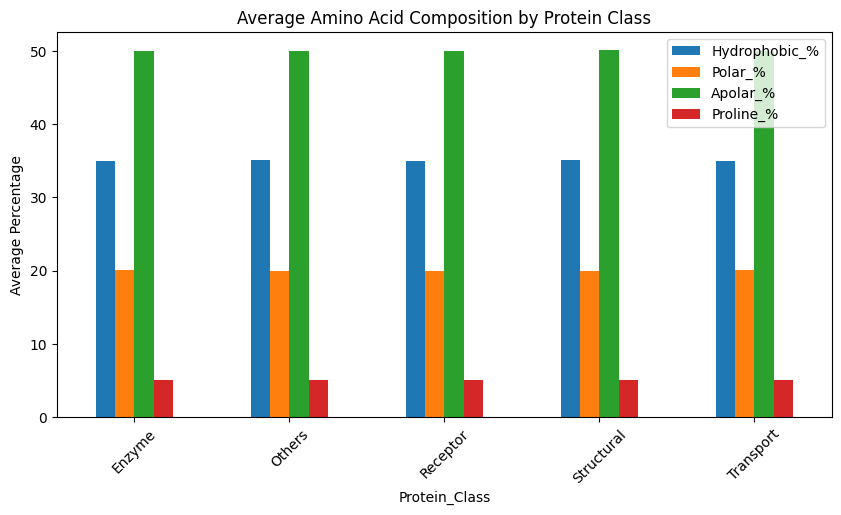

In [51]:
avg = df.groupby("Protein_Class")[[
    "Hydrophobic_%",
    "Polar_%",
    "Apolar_%",
    "Proline_%"
]].mean()

avg.plot(kind="bar", figsize=(10,5))

plt.ylabel("Average Percentage")
plt.title("Average Amino Acid Composition by Protein Class")
plt.xticks(rotation=45)

plt.show()

In [53]:
df.columns

Index(['Protein_ID', 'Protein_Sequence', 'Molecular_Weight',
       'Isoelectric_Point', 'Hydrophobicity', 'Total_Charge', 'Polar_Content',
       'Apolar_Content', 'Sequence_Length', 'Protein_Class', 'Weight_Class',
       'Hydrophobic_Count', 'Hydrophobic_%', 'Hydrophilic_Count',
       'Hydrophilic_%', 'Polar_Count', 'Polar_%', 'Apolar_Count', 'Apolar_%',
       'Basic_Count', 'Basic_%', 'Acidic_Count', 'Acidic_%', 'Proline_Count',
       'Proline_%', 'Basic_Acidic_Ratio'],
      dtype='object')

In [54]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

df["Instability_Index"] = df["Protein_Sequence"].apply(
    lambda x: ProteinAnalysis(x).instability_index()
)

df["Stability"] = df["Instability_Index"].apply(
    lambda x: "Stable" if x < 40 else "Unstable"
)

df["Stability"].value_counts()

(df["Stability"].value_counts(normalize=True) * 100).round(2)

Stability
Unstable    69.15
Stable      30.85
Name: proportion, dtype: float64

In [55]:
def aliphatic_index(seq):
    length = len(seq)

    A = seq.count("A") / length * 100
    V = seq.count("V") / length * 100
    I = seq.count("I") / length * 100
    L = seq.count("L") / length * 100

    return A + 2.9 * V + 3.9 * (I + L)

df["Aliphatic_Index"] = df["Protein_Sequence"].apply(aliphatic_index)
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Basic_Count,Basic_%,Acidic_Count,Acidic_%,Proline_Count,Proline_%,Basic_Acidic_Ratio,Instability_Index,Stability,Aliphatic_Index
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,33,15.789474,29,13.875598,12,5.741627,1.100000,41.863158,Unstable,59.234450
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,24,13.407821,21,11.731844,3,1.675978,1.090909,27.954190,Stable,64.692737
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,21,14.093960,12,8.053691,5,3.355705,1.615385,35.593289,Stable,66.711409
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,13,13.265306,6,6.122449,3,3.061224,1.857143,37.018367,Stable,66.632653
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,25,13.297872,20,10.638298,6,3.191489,1.190476,20.081383,Stable,55.531915


In [56]:
df.nlargest(10,"Aliphatic_Index")[["Protein_ID","Protein_Class","Aliphatic_Index"]]

,Protein_ID,Protein_Class,Aliphatic_Index
26933,P26934,Transport,137.222222
30577,P30578,Enzyme,120.740741
4901,P04902,Receptor,118.513514
11752,P11753,Receptor,117.792208
21746,P21747,Enzyme,115.913043
30820,P30821,Structural,115.090909
26399,P26400,Receptor,114.385965
19226,P19227,Others,113.962264
19096,P19097,Others,113.387097
38088,P38089,Others,113.375000


In [57]:
df["Aromaticity"] = df["Protein_Sequence"].apply(lambda x: ProteinAnalysis(x).aromaticity())
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Basic_%,Acidic_Count,Acidic_%,Proline_Count,Proline_%,Basic_Acidic_Ratio,Instability_Index,Stability,Aliphatic_Index,Aromaticity
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,15.789474,29,13.875598,12,5.741627,1.100000,41.863158,Unstable,59.234450,0.119617
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,13.407821,21,11.731844,3,1.675978,1.090909,27.954190,Stable,64.692737,0.162011
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,14.093960,12,8.053691,5,3.355705,1.615385,35.593289,Stable,66.711409,0.114094
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,13.265306,6,6.122449,3,3.061224,1.857143,37.018367,Stable,66.632653,0.173469
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,13.297872,20,10.638298,6,3.191489,1.190476,20.081383,Stable,55.531915,0.180851


In [58]:
df.nlargest(10,"Aromaticity")[["Protein_ID","Protein_Class","Aromaticity"]]

,Protein_ID,Protein_Class,Aromaticity
52857,P52858,Enzyme,0.323077
26347,P26348,Structural,0.321429
58167,P58168,Structural,0.313253
640,P00641,Receptor,0.309091
41146,P41147,Enzyme,0.309091
26583,P26584,Receptor,0.307692
11700,P11701,Receptor,0.307692
5561,P05562,Enzyme,0.301887
46752,P46753,Structural,0.301587
33101,P33102,Structural,0.300000


In [59]:
df["GRAVY"] = df["Protein_Sequence"].apply(lambda x: ProteinAnalysis(x).gravy())

In [60]:
df["GRAVY"].describe()

count    60000.000000
mean        -0.490168
std          0.246402
min         -1.796429
25%         -0.643806
50%         -0.491808
75%         -0.336621
max          1.056000
Name: GRAVY, dtype: float64

In [61]:
df["Flexibility"] = df["Protein_Sequence"].apply(lambda x: sum(ProteinAnalysis(x).flexibility()) / len(ProteinAnalysis(x).flexibility()))

In [62]:
def secondary_structure(seq):
    helix, turn, sheet = ProteinAnalysis(seq).secondary_structure_fraction()
    return pd.Series([helix, turn, sheet])

df[["Helix","Turn","Sheet"]] = df["Protein_Sequence"].apply(secondary_structure)

In [63]:
df.head(10)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Basic_Acidic_Ratio,Instability_Index,Stability,Aliphatic_Index,Aromaticity,GRAVY,Flexibility,Helix,Turn,Sheet
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,1.100000,41.863158,Unstable,59.234450,0.119617,-0.673206,0.995121,0.234450,0.287081,0.325359
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,1.090909,27.954190,Stable,64.692737,0.162011,-0.392179,0.993407,0.301676,0.245810,0.374302
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,1.615385,35.593289,Stable,66.711409,0.114094,-0.124832,0.986617,0.241611,0.241611,0.335570
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,1.857143,37.018367,Stable,66.632653,0.173469,-0.533673,0.988577,0.204082,0.244898,0.418367
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,1.190476,20.081383,Stable,55.531915,0.180851,-0.470745,0.990228,0.265957,0.228723,0.393617
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptor,...,1.428571,40.110711,Unstable,62.845850,0.134387,-0.453755,0.989116,0.284585,0.209486,0.347826
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Others,...,1.714286,51.059091,Unstable,58.246753,0.116883,-0.417532,0.987270,0.233766,0.220779,0.305195
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzyme,...,1.153846,42.042187,Unstable,70.156250,0.078125,-0.335938,0.997958,0.296875,0.296875,0.289062
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Structural,...,1.111111,48.045055,Unstable,57.875458,0.120879,-0.526007,0.997827,0.285714,0.289377,0.318681
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzyme,...,1.666667,52.917949,Unstable,75.042735,0.179487,-0.539316,0.988915,0.282051,0.205128,0.393162


In [64]:
df.groupby("Protein_Class")[["Helix","Turn","Sheet"]].mean()

,Helix,Turn,Sheet
Protein_Class,,,
Enzyme,0.249835,0.250479,0.349786
Others,0.249694,0.249800,0.350285
Receptor,0.250548,0.249845,0.349602
Structural,0.250029,0.249811,0.350152
Transport,0.250108,0.249906,0.349939


In [65]:
stability_summary = df.groupby("Protein_Class").agg({

    "Instability_Index":"mean",
    "Aliphatic_Index":"mean",
    "GRAVY":"mean",
    "Aromaticity":"mean",
    "Flexibility":"mean"

}).round(2)

stability_summary

,Instability_Index,Aliphatic_Index,GRAVY,Aromaticity,Flexibility
Protein_Class,,,,,
Enzyme,45.27,58.51,-0.49,0.15,0.99
Others,45.37,58.67,-0.49,0.15,0.99
Receptor,45.33,58.53,-0.49,0.15,0.99
Structural,45.59,58.52,-0.49,0.15,0.99
Transport,45.61,58.46,-0.49,0.15,0.99


In [66]:
features = [
    "Instability_Index",
    "Aliphatic_Index",
    "GRAVY",
    "Hydrophobic_%",
    "Polar_%",
    "Proline_%",
    "Molecular_Weight",
    "Isoelectric_Point",
    "Total_Charge"
]

df[features].corr()

,Instability_Index,Aliphatic_Index,GRAVY,Hydrophobic_%,Polar_%,Proline_%,Molecular_Weight,Isoelectric_Point,Total_Charge
Instability_Index,1.000000,-0.096069,-0.097233,-0.039809,-0.017200,0.180158,0.024947,0.011837,0.045626
Aliphatic_Index,-0.096069,1.000000,0.694944,0.617929,-0.231162,-0.106396,-0.015884,-0.004700,-0.040959
GRAVY,-0.097233,0.694944,1.000000,0.896896,-0.284259,-0.087841,-0.009386,-0.087427,-0.113613
Hydrophobic_%,-0.039809,0.617929,0.896896,1.000000,-0.369633,-0.170733,-0.006171,-0.031965,-0.058801
Polar_%,-0.017200,-0.231162,-0.284259,-0.369633,1.000000,-0.108440,-0.011204,0.001642,-0.037812
Proline_%,0.180158,-0.106396,-0.087841,-0.170733,-0.108440,1.000000,-0.010766,0.003045,-0.014679
Molecular_Weight,0.024947,-0.015884,-0.009386,-0.006171,-0.011204,-0.010766,1.000000,0.053864,0.491634
Isoelectric_Point,0.011837,-0.004700,-0.087427,-0.031965,0.001642,0.003045,0.053864,1.000000,0.764733
Total_Charge,0.045626,-0.040959,-0.113613,-0.058801,-0.037812,-0.014679,0.491634,0.764733,1.000000


In [67]:
def classify_pI(pI):

    if pI < 4.5:
        return "Strongly Acidic"

    elif pI < 6.0:
        return "Acidic"

    elif pI < 6.8:
        return "Weakly Acidic"

    elif pI <= 7.4:
        return "Near Neutral"

    elif pI < 8.9:
        return "Weakly Basic"

    elif pI < 9.5:
        return "Basic"

    elif pI < 11.5:
        return "Highly Basic"

    else:
        return "Strongly Basic"

df["PI_Class"] = df["Isoelectric_Point"].apply(classify_pI)
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Instability_Index,Stability,Aliphatic_Index,Aromaticity,GRAVY,Flexibility,Helix,Turn,Sheet,PI_Class
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,41.863158,Unstable,59.234450,0.119617,-0.673206,0.995121,0.234450,0.287081,0.325359,Acidic
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,27.954190,Stable,64.692737,0.162011,-0.392179,0.993407,0.301676,0.245810,0.374302,Acidic
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,35.593289,Stable,66.711409,0.114094,-0.124832,0.986617,0.241611,0.241611,0.335570,Near Neutral
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,37.018367,Stable,66.632653,0.173469,-0.533673,0.988577,0.204082,0.244898,0.418367,Weakly Basic
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,20.081383,Stable,55.531915,0.180851,-0.470745,0.990228,0.265957,0.228723,0.393617,Near Neutral


In [68]:
def classify_pI_numeric(pI):

    if pI < 4.5:
        return -4

    elif pI < 6.0:
        return -3

    elif pI < 6.8:
        return -2

    elif pI <= 7.4:
        return 0

    elif pI < 8.9:
        return 1

    elif pI < 9.5:
        return 2

    elif pI < 11.5:
        return 3

    else:
        return 4

df["PI_Class_Num"] = df["Isoelectric_Point"].apply(classify_pI_numeric)
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Stability,Aliphatic_Index,Aromaticity,GRAVY,Flexibility,Helix,Turn,Sheet,PI_Class,PI_Class_Num
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,Unstable,59.234450,0.119617,-0.673206,0.995121,0.234450,0.287081,0.325359,Acidic,-3
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,Stable,64.692737,0.162011,-0.392179,0.993407,0.301676,0.245810,0.374302,Acidic,-3
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,Stable,66.711409,0.114094,-0.124832,0.986617,0.241611,0.241611,0.335570,Near Neutral,0
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,Stable,66.632653,0.173469,-0.533673,0.988577,0.204082,0.244898,0.418367,Weakly Basic,1
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,Stable,55.531915,0.180851,-0.470745,0.990228,0.265957,0.228723,0.393617,Near Neutral,0


In [69]:
def molecular_class(mw):

    if mw < 10000:
        return "Small"

    elif mw < 30000:
        return "Medium"

    elif mw < 70000:
        return "Large"

    else:
        return "Very Large"

df["Molecular_Weight_Level"] = df["Molecular_Weight"].apply(molecular_class)

In [70]:
def molecular_class_num(mw):

    if mw < 10000:
        return 0

    elif mw < 30000:
        return 1

    elif mw < 70000:
        return 2

    else:
        return 3

df["Molecular_Weight_Level_Num"] = df["Molecular_Weight"].apply(molecular_class_num)

In [71]:
df.Sequence_Length

0        209
1        179
2        149
3         98
4        188
        ... 
59995    150
59996    120
59997     81
59998    250
59999    191
Name: Sequence_Length, Length: 60000, dtype: int64

In [72]:
def sequence_size(length):
    if length < 100:
        return "Short"
    elif length < 150:
        return "Medium"
    elif length < 200:
        return "Long"
    else:
        return "Very Long"

df["Sequence_Length_Class"] = df["Sequence_Length"].apply(sequence_size)

In [73]:
df.Hydrophobicity

0        0.105263
1        0.150838
2        0.171141
3        0.173469
4        0.162234
           ...   
59995    0.143333
59996    0.179167
59997    0.086420
59998    0.162000
59999    0.130890
Name: Hydrophobicity, Length: 60000, dtype: float64

In [74]:
df["Hydrophobicity"].describe()

count    60000.000000
mean         0.149968
std          0.027094
min          0.000000
25%          0.133136
50%          0.150000
75%          0.166667
max          0.289474
Name: Hydrophobicity, dtype: float64

In [75]:
df["Hydrophobicity"].quantile([0.2, 0.4, 0.6, 0.8])

0.2    0.128788
0.4    0.143836
0.6    0.156425
0.8    0.171363
Name: Hydrophobicity, dtype: float64

In [76]:
df["Hydrophobicity_Level"] = pd.qcut(
    df["Hydrophobicity"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [77]:
df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Flexibility,Helix,Turn,Sheet,PI_Class,PI_Class_Num,Molecular_Weight_Level,Molecular_Weight_Level_Num,Sequence_Length_Class,Hydrophobicity_Level
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,0.995121,0.234450,0.287081,0.325359,Acidic,-3,Medium,1,Very Long,Very Low
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,0.993407,0.301676,0.245810,0.374302,Acidic,-3,Medium,1,Long,Moderate
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,0.986617,0.241611,0.241611,0.335570,Near Neutral,0,Medium,1,Medium,High
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,0.988577,0.204082,0.244898,0.418367,Weakly Basic,1,Medium,1,Short,Very High
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,0.990228,0.265957,0.228723,0.393617,Near Neutral,0,Medium,1,Long,High


In [78]:
def charge_class(c):

    if c < -5:
        return "Highly Negative"

    elif c < 0:
        return "Negative"

    elif c == 0:
        return "Neutral"

    elif c < 5:
        return "Positive"

    else:
        return "Highly Positive"

df["Charge_Class"] = df["Total_Charge"].apply(charge_class)

In [79]:
df["Instability_Index"] = df["Protein_Sequence"].apply(lambda x: ProteinAnalysis(x).instability_index())

def stability(idx):

    if idx < 40:
        return "Stable"

    return "Unstable"

df["Stability"] = df["Instability_Index"].apply(stability)

df.head(5)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Helix,Turn,Sheet,PI_Class,PI_Class_Num,Molecular_Weight_Level,Molecular_Weight_Level_Num,Sequence_Length_Class,Hydrophobicity_Level,Charge_Class
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,0.234450,0.287081,0.325359,Acidic,-3,Medium,1,Very Long,Very Low,Positive
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,0.301676,0.245810,0.374302,Acidic,-3,Medium,1,Long,Moderate,Positive
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,0.241611,0.241611,0.335570,Near Neutral,0,Medium,1,Medium,High,Highly Positive
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,0.204082,0.244898,0.418367,Weakly Basic,1,Medium,1,Short,Very High,Highly Positive
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,0.265957,0.228723,0.393617,Near Neutral,0,Medium,1,Long,High,Highly Positive


In [80]:
df["Polar_%"].head(10)

0    21.052632
1    18.994413
2    18.120805
3    27.551020
4    20.212766
5    18.181818
6    20.129870
7    21.875000
8    19.413919
9    14.529915
Name: Polar_%, dtype: float64

In [81]:
def polar_class(p):

    if p < 15:
        return "Low"

    elif p < 30:
        return "Moderate"

    else:
        return "High"

df["Polar_Level"] = df["Polar_%"].apply(polar_class)

In [82]:
df["Hydrophobic_%"].head(10)

0    31.578947
1    34.636872
2    40.939597
3    31.632653
4    34.574468
5    36.758893
6    38.311688
7    39.062500
8    34.432234
9    33.333333
Name: Hydrophobic_%, dtype: float64

In [83]:
def hydro_class(h):

    if h < 20:
        return "Low"

    elif h < 35:
        return "Moderate"

    elif h < 50:
        return "High"

    else:
        return "Very High"

df["Hydrophobic_Content"] = df["Hydrophobic_%"].apply(hydro_class)

In [84]:
df["Charge_Density"] = (df["Total_Charge"] /df["Sequence_Length"])

df["Mass_per_Residue"] = (df["Molecular_Weight"] /df["Sequence_Length"])

df["Hydrophobic_Polar_Ratio"] = (df["Hydrophobic_%"] /(df["Polar_%"] + 0.01))

df["Apolar_Polar_Ratio"] = (df["Apolar_%"] /(df["Polar_%"] + 0.01))

In [85]:
df.head(10)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Molecular_Weight_Level_Num,Sequence_Length_Class,Hydrophobicity_Level,Charge_Class,Polar_Level,Hydrophobic_Content,Charge_Density,Mass_per_Residue,Hydrophobic_Polar_Ratio,Apolar_Polar_Ratio
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,1,Very Long,Very Low,Positive,Moderate,Moderate,0.019139,118.025853,1.499288,2.226215
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,1,Long,Moderate,Positive,Moderate,Moderate,0.016760,118.905425,1.822570,2.704459
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,1,Medium,High,Highly Positive,Moderate,High,0.060403,115.811911,2.258013,3.257462
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,1,Short,Very High,Highly Positive,Moderate,Moderate,0.071429,120.328479,1.147732,1.666062
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,1,Long,High,Highly Positive,Moderate,Moderate,0.026596,120.434632,1.709680,2.419855
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptor,...,2,Very Long,Moderate,Highly Positive,Moderate,High,0.051383,120.062274,2.020628,2.867988
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Others,...,1,Long,High,Highly Positive,Moderate,High,0.071429,116.671455,1.902281,2.579364
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzyme,...,1,Medium,Moderate,Positive,Moderate,High,0.023438,113.435093,1.784898,2.498858
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Structural,...,2,Very Long,Low,Highly Positive,Moderate,Moderate,0.018315,115.488481,1.772672,2.508142
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzyme,...,1,Medium,Very High,Highly Positive,Low,Moderate,0.076923,121.265385,2.292540,3.291852


In [86]:
import matplotlib.pyplot as plt

In [87]:
pi_distribution = df["PI_Class"].value_counts().sort_index()

print(pi_distribution)

PI_Class
Acidic             13247
Basic               7264
Highly Basic        2061
Near Neutral        5824
Strongly Acidic      619
Strongly Basic         5
Weakly Acidic      12517
Weakly Basic       18463
Name: count, dtype: int64


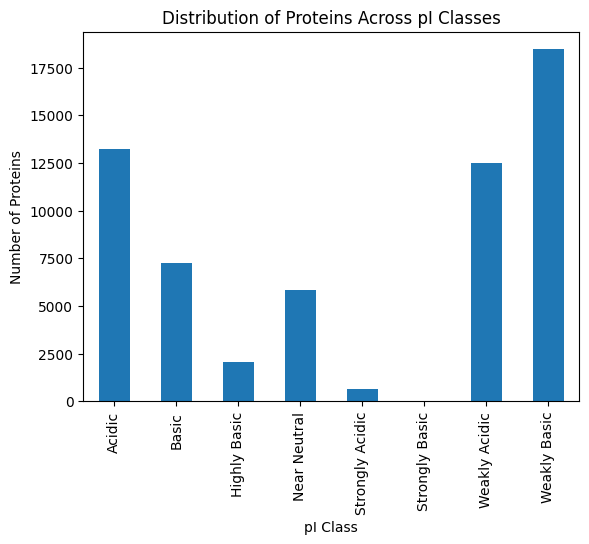

In [88]:
pi_distribution.plot(kind="bar")

plt.title("Distribution of Proteins Across pI Classes")
plt.xlabel("pI Class")
plt.ylabel("Number of Proteins")

plt.show()

In [89]:
pi_class_table = pd.crosstab(df["PI_Class"], df["Protein_Class"])

print(pi_class_table)

Protein_Class    Enzyme  Others  Receptor  Structural  Transport
PI_Class                                                        
Acidic             2642    2758      2551        2625       2671
Basic              1427    1476      1474        1455       1432
Highly Basic        411     391       412         423        424
Near Neutral       1138    1184      1172        1197       1133
Strongly Acidic     130     115       110         141        123
Strongly Basic        2       1         1           1          0
Weakly Acidic      2513    2532      2473        2460       2539
Weakly Basic       3691    3759      3657        3689       3667


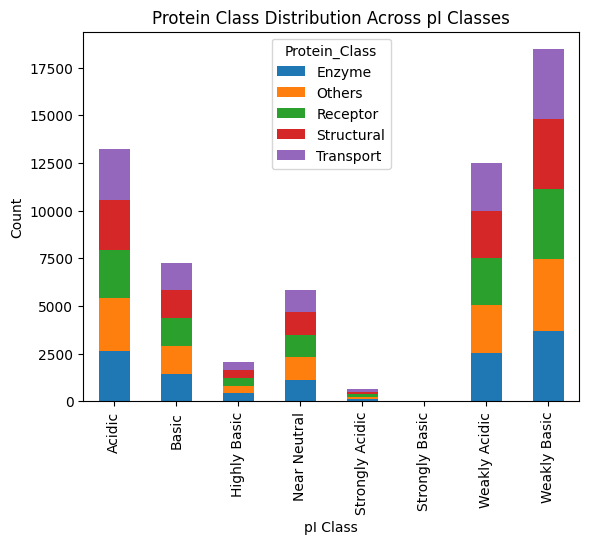

In [90]:
pi_class_table.plot(kind="bar", stacked=True)

plt.title("Protein Class Distribution Across pI Classes")
plt.xlabel("pI Class")
plt.ylabel("Count")

plt.show()

In [91]:
instability_summary = df.groupby("Molecular_Weight_Level")["Instability_Index"].agg(
    ["mean","median","min","max","std"]
).round(5)

print(instability_summary)

                            mean    median       min        max       std
Molecular_Weight_Level                                                   
Large                   45.75742  45.64549  15.79821   81.61860   8.04379
Medium                  45.43712  45.15926  -4.88043  108.48152  10.85515
Small                   44.96394  44.34194  -6.45660  110.03519  16.14890


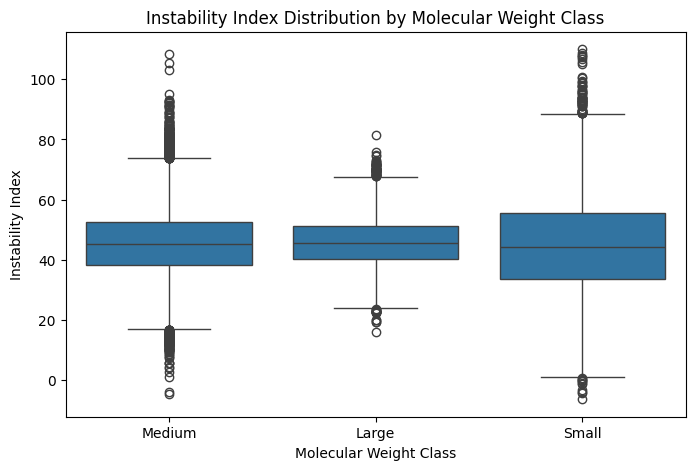

In [92]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Molecular_Weight_Level",
    y="Instability_Index"
)

plt.title("Instability Index Distribution by Molecular Weight Class")
plt.xlabel("Molecular Weight Class")
plt.ylabel("Instability Index")

plt.show()

In [93]:
stability_table = pd.crosstab(
    df["Protein_Class"],
    df["Stability"]
)

print(stability_table)

Stability      Stable  Unstable
Protein_Class                  
Enzyme           3794      8160
Others           3793      8423
Receptor         3663      8187
Structural       3618      8373
Transport        3640      8349


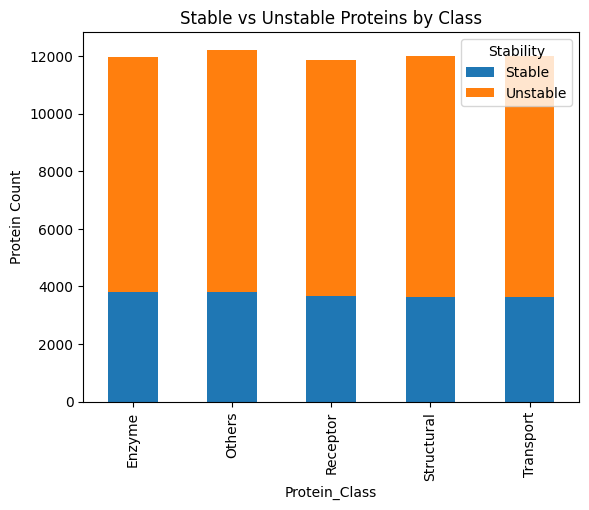

In [94]:
stability_table.plot(
    kind="bar",
    stacked=True
)

plt.title("Stable vs Unstable Proteins by Class")
plt.ylabel("Protein Count")

plt.show()

In [95]:
stability_percent = pd.crosstab(
    df["Protein_Class"],
    df["Stability"],
    normalize="index") * 100

print(stability_percent.round(5))

Stability        Stable  Unstable
Protein_Class                    
Enzyme         31.73833  68.26167
Others         31.04944  68.95056
Receptor       30.91139  69.08861
Structural     30.17263  69.82737
Transport      30.36116  69.63884


In [96]:
hydro_table = pd.crosstab(df["Protein_Class"], df["Hydrophobicity_Level"])

print(hydro_table)

Hydrophobicity_Level  Very Low   Low  Moderate  High  Very High
Protein_Class                                                  
Enzyme                    2320  2455      2431  2425       2323
Others                    2429  2481      2420  2456       2430
Receptor                  2385  2316      2385  2353       2411
Structural                2397  2365      2388  2388       2453
Transport                 2470  2410      2349  2377       2383


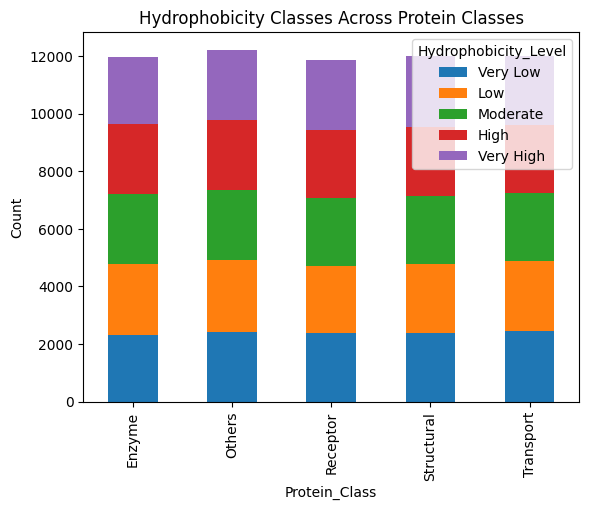

In [97]:
hydro_table.plot(
    kind="bar",
    stacked=True
)

plt.title("Hydrophobicity Classes Across Protein Classes")
plt.ylabel("Count")

plt.show()

In [98]:
df.groupby("Sequence_Length_Class")["Instability_Index"].mean().round(2)

Sequence_Length_Class
Long         45.54
Medium       45.28
Short        45.03
Very Long    45.65
Name: Instability_Index, dtype: float64

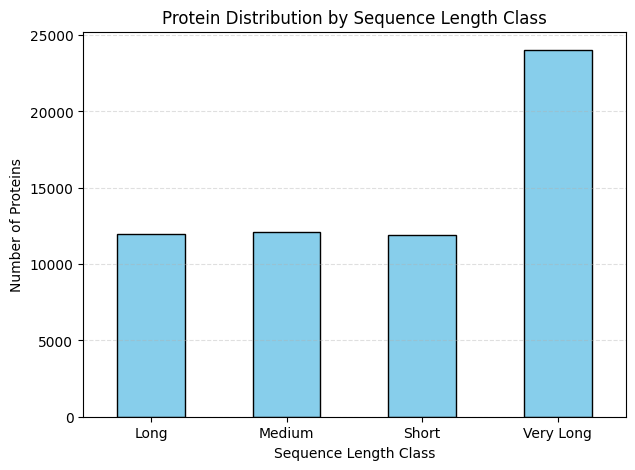

In [99]:
plt.figure(figsize=(7,5))

df["Sequence_Length_Class"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black",
    color="skyblue"
)

plt.xlabel("Sequence Length Class")
plt.ylabel("Number of Proteins")
plt.title("Protein Distribution by Sequence Length Class")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

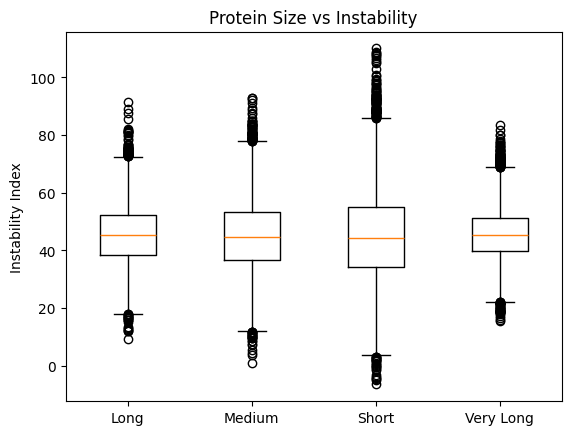

In [100]:
groups=[]

labels=[]

for g,data in df.groupby("Sequence_Length_Class"):
    groups.append(data["Instability_Index"])
    labels.append(g)

plt.boxplot(groups, tick_labels=labels)

plt.ylabel("Instability Index")

plt.title("Protein Size vs Instability")

plt.show()

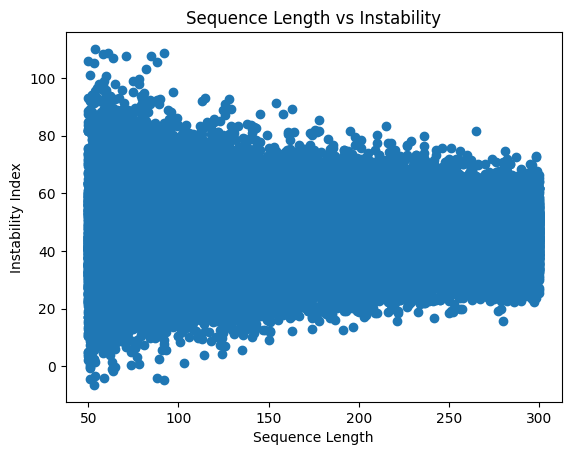

In [101]:
plt.scatter(
    df["Sequence_Length"],
    df["Instability_Index"]
)

plt.xlabel("Sequence Length")

plt.ylabel("Instability Index")

plt.title("Sequence Length vs Instability")

plt.show()

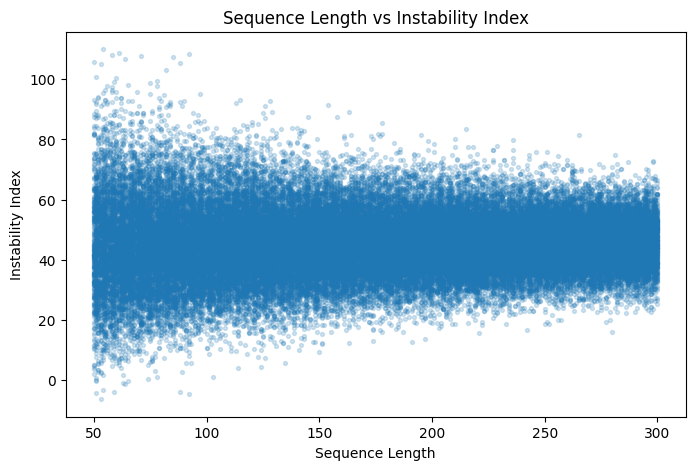

In [102]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Sequence_Length"],
    df["Instability_Index"],
    s=8,          # smaller points
    alpha=0.2     # transparency
)

plt.xlabel("Sequence Length")
plt.ylabel("Instability Index")
plt.title("Sequence Length vs Instability Index")

plt.show()

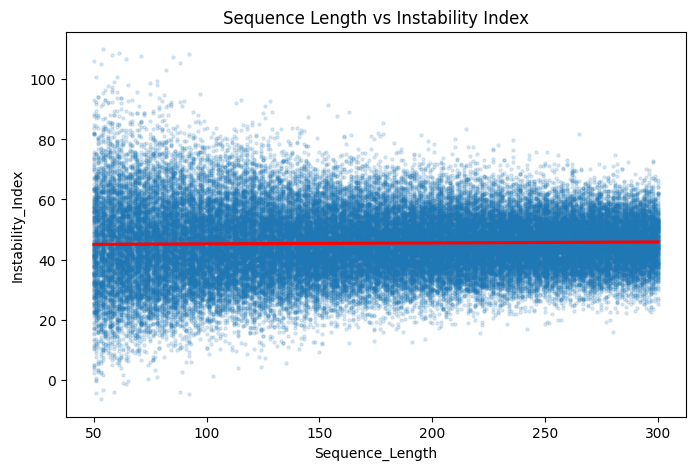

In [103]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Sequence_Length",
    y="Instability_Index",
    scatter_kws={"s":5, "alpha":0.15},
    line_kws={"color":"red"}
)

plt.title("Sequence Length vs Instability Index")
plt.show()

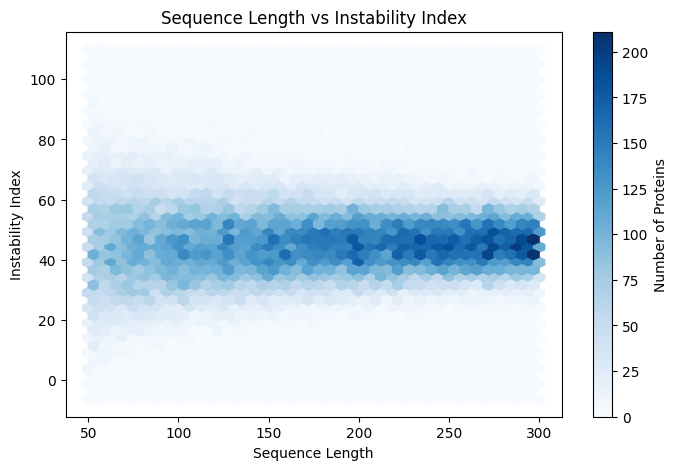

In [104]:
plt.figure(figsize=(8,5))

plt.hexbin(
    df["Sequence_Length"],
    df["Instability_Index"],
    gridsize=40,
    cmap="Blues"
)

plt.colorbar(label="Number of Proteins")

plt.xlabel("Sequence Length")
plt.ylabel("Instability Index")
plt.title("Sequence Length vs Instability Index")

plt.show()

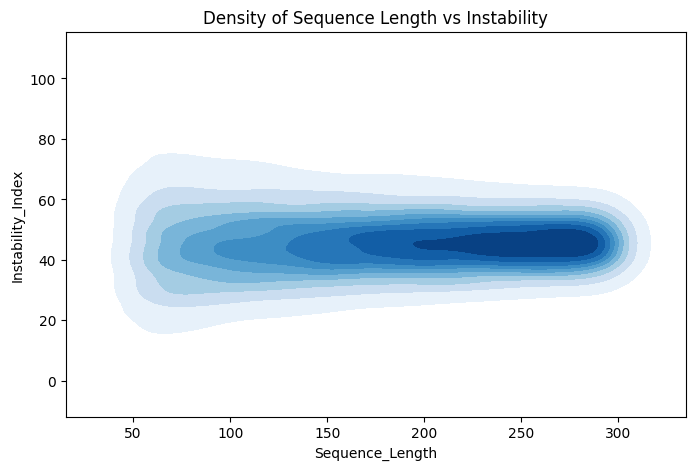

In [105]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Sequence_Length",
    y="Instability_Index",
    fill=True,
    cmap="Blues"
)

plt.title("Density of Sequence Length vs Instability")
plt.show()

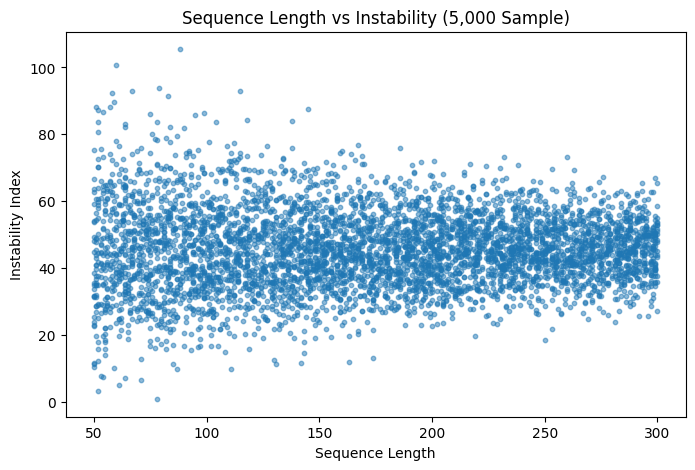

In [106]:
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(
    sample["Sequence_Length"],
    sample["Instability_Index"],
    s=10,
    alpha=0.5
)

plt.xlabel("Sequence Length")
plt.ylabel("Instability Index")
plt.title("Sequence Length vs Instability (5,000 Sample)")

plt.show()

In [107]:
corr = df["Sequence_Length"].corr(df["Instability_Index"])

print(f"Correlation: {corr:.3f}")

Correlation: 0.021


In [108]:
from scipy.stats import pearsonr

r, p = pearsonr(df["Sequence_Length"], df["Instability_Index"])

print(f"Correlation coefficient (r): {r:.3f}")
print(f"P-value: {p:.5f}")

Correlation coefficient (r): 0.021
P-value: 0.00000


In [109]:
features = [
"Charge_Density",
"Hydrophobic_Polar_Ratio",
"Mass_per_Residue",
"Molecular_Weight",
"Sequence_Length",
"Isoelectric_Point"
]

corr = df[features].corr()

print(corr.round(3))

                         Charge_Density  Hydrophobic_Polar_Ratio  \
Charge_Density                    1.000                   -0.007   
Hydrophobic_Polar_Ratio          -0.007                    1.000   
Mass_per_Residue                  0.192                    0.048   
Molecular_Weight                  0.011                   -0.071   
Sequence_Length                   0.003                   -0.073   
Isoelectric_Point                 0.889                   -0.021   

                         Mass_per_Residue  Molecular_Weight  Sequence_Length  \
Charge_Density                      0.192             0.011            0.003   
Hydrophobic_Polar_Ratio             0.048            -0.071           -0.073   
Mass_per_Residue                    1.000             0.021           -0.020   
Molecular_Weight                    0.021             1.000            0.999   
Sequence_Length                    -0.020             0.999            1.000   
Isoelectric_Point                   0.156  

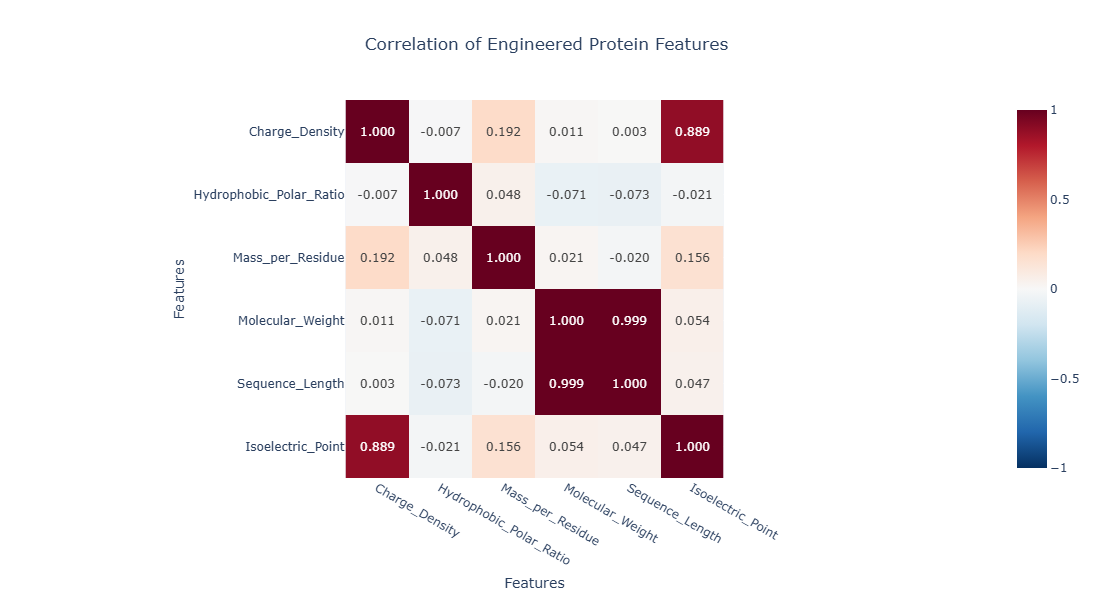

In [110]:
import plotly.express as px

fig = px.imshow(
    corr,
    text_auto=".3f",                  
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation of Engineered Protein Features"
)

fig.update_layout(
    width=700,
    height=600,
    xaxis_title="Features",
    yaxis_title="Features",
    title_x=0.5
)

fig.update_xaxes(side="bottom")

fig.show()

In [111]:
stability_pi = pd.crosstab(df["PI_Class"], df["Stability"])

print(stability_pi)

Stability        Stable  Unstable
PI_Class                         
Acidic             4308      8939
Basic              2302      4962
Highly Basic        681      1380
Near Neutral       1741      4083
Strongly Acidic     240       379
Strongly Basic        1         4
Weakly Acidic      3661      8856
Weakly Basic       5574     12889


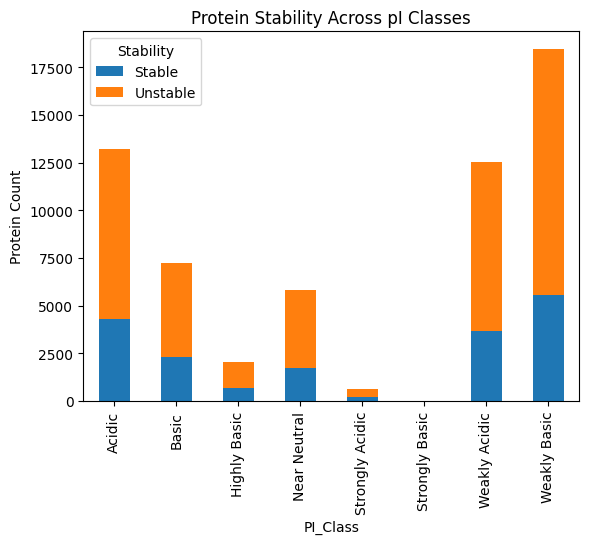

In [112]:
stability_pi.plot(
    kind="bar",
    stacked=True
)

plt.title("Protein Stability Across pI Classes")

plt.ylabel("Protein Count")

plt.show()

In [113]:
df.columns

Index(['Protein_ID', 'Protein_Sequence', 'Molecular_Weight',
       'Isoelectric_Point', 'Hydrophobicity', 'Total_Charge', 'Polar_Content',
       'Apolar_Content', 'Sequence_Length', 'Protein_Class', 'Weight_Class',
       'Hydrophobic_Count', 'Hydrophobic_%', 'Hydrophilic_Count',
       'Hydrophilic_%', 'Polar_Count', 'Polar_%', 'Apolar_Count', 'Apolar_%',
       'Basic_Count', 'Basic_%', 'Acidic_Count', 'Acidic_%', 'Proline_Count',
       'Proline_%', 'Basic_Acidic_Ratio', 'Instability_Index', 'Stability',
       'Aliphatic_Index', 'Aromaticity', 'GRAVY', 'Flexibility', 'Helix',
       'Turn', 'Sheet', 'PI_Class', 'PI_Class_Num', 'Molecular_Weight_Level',
       'Molecular_Weight_Level_Num', 'Sequence_Length_Class',
       'Hydrophobicity_Level', 'Charge_Class', 'Polar_Level',
       'Hydrophobic_Content', 'Charge_Density', 'Mass_per_Residue',
       'Hydrophobic_Polar_Ratio', 'Apolar_Polar_Ratio'],
      dtype='object')

Hydrophobicity_Level    Very Low   Low  Moderate  High  Very High
Molecular_Weight_Level                                           
Large                       1557  2696      2928  2761       1545
Medium                      7965  8138      7993  8105       8085
Small                       2479  1193      1052  1133       2370


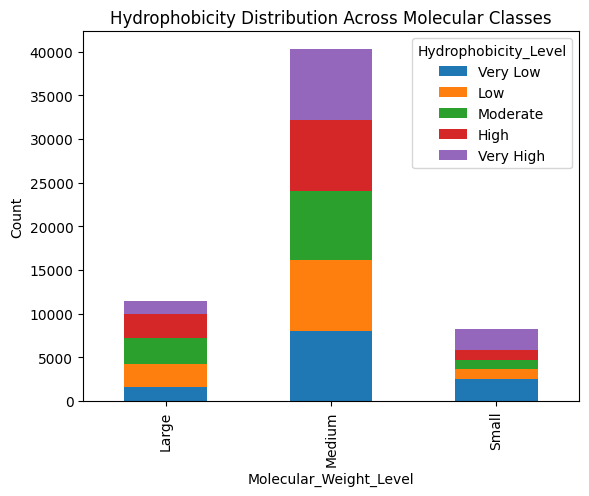

In [114]:
molecular_hydro = pd.crosstab(df["Molecular_Weight_Level"], df["Hydrophobicity_Level"])

print(molecular_hydro)

molecular_hydro.plot(
    kind="bar",
    stacked=True
)

plt.title("Hydrophobicity Distribution Across Molecular Classes")

plt.ylabel("Count")

plt.show()

In [115]:
summary = df.groupby("Protein_Class").agg({

"Molecular_Weight":"mean",

"Sequence_Length":"mean",

"Isoelectric_Point":"mean",

"Instability_Index":"mean",

"Hydrophobic_%":"mean",

"Polar_%":"mean",

"Apolar_%":"mean",

"Proline_%":"mean",

"Charge_Density":"mean"

}).round(5)

print(summary)

               Molecular_Weight  Sequence_Length  Isoelectric_Point  \
Protein_Class                                                         
Enzyme              20858.18234        175.31195            7.25755   
Others              20785.99013        174.65488            7.24817   
Receptor            20821.13785        174.99806            7.28053   
Structural          20719.46995        174.09282            7.26158   
Transport           20805.91790        174.82726            7.25127   

               Instability_Index  Hydrophobic_%   Polar_%  Apolar_%  \
Protein_Class                                                         
Enzyme                  45.27126       34.94932  20.03495  49.98126   
Others                  45.36796       35.03560  19.96781  50.03978   
Receptor                45.32813       35.03093  20.00611  50.00825   
Structural              45.58920       35.08059  19.93334  50.08556   
Transport               45.61076       34.96153  20.02334  49.95822   

    

In [116]:
df.head(10)

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Molecular_Weight_Level_Num,Sequence_Length_Class,Hydrophobicity_Level,Charge_Class,Polar_Level,Hydrophobic_Content,Charge_Density,Mass_per_Residue,Hydrophobic_Polar_Ratio,Apolar_Polar_Ratio
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,1,Very Long,Very Low,Positive,Moderate,Moderate,0.019139,118.025853,1.499288,2.226215
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,1,Long,Moderate,Positive,Moderate,Moderate,0.016760,118.905425,1.822570,2.704459
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,1,Medium,High,Highly Positive,Moderate,High,0.060403,115.811911,2.258013,3.257462
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,1,Short,Very High,Highly Positive,Moderate,Moderate,0.071429,120.328479,1.147732,1.666062
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,1,Long,High,Highly Positive,Moderate,Moderate,0.026596,120.434632,1.709680,2.419855
5,P00006,AQMGCNQNWLKCDEIRGEELIVHIATPEIDWGPGTVDTPWLHLEAF...,30375.7554,6.503995,0.150198,13,0.181818,0.407115,253,Receptor,...,2,Very Long,Moderate,Highly Positive,Moderate,High,0.051383,120.062274,2.020628,2.867988
6,P00007,WAHDANQDVQFAAVLIISLCVTYPVTIIIRQHPCMSACKWVQQMHA...,17967.4041,7.745358,0.159091,11,0.201299,0.402597,154,Others,...,1,Long,High,Highly Positive,Moderate,High,0.071429,116.671455,1.902281,2.579364
7,P00008,PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...,14519.6919,6.210876,0.144531,3,0.218750,0.382812,128,Enzyme,...,1,Medium,Moderate,Positive,Moderate,High,0.023438,113.435093,1.784898,2.498858
8,P00009,GVTSKMTGSLSIDWNIEYIMRSPYWGMDFQTEHGNEMNNICRYTIA...,31528.3554,5.945154,0.137363,5,0.194139,0.402930,273,Structural,...,2,Very Long,Low,Highly Positive,Moderate,Moderate,0.018315,115.488481,1.772672,2.508142
9,P00010,AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...,14188.0501,8.842306,0.192308,9,0.145299,0.478632,117,Enzyme,...,1,Medium,Very High,Highly Positive,Low,Moderate,0.076923,121.265385,2.292540,3.291852


In [121]:
df.to_csv("Proteins_Analysed.csv", index=False)

In [118]:
df.to_excel("Proteins_Analysed.xlsx", index=False)

In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================================
# Features Selection
# ===============================================

features = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Mass_per_Residue",
    "Charge_Density",
    "Hydrophobic_Polar_Ratio"
]

X = df[features]
X.head(10)

,Isoelectric_Point,Hydrophobicity,Instability_Index,Aliphatic_Index,Aromaticity,GRAVY,Flexibility,Mass_per_Residue,Charge_Density,Hydrophobic_Polar_Ratio
0,5.655161,0.105263,41.863158,59.234450,0.119617,-0.673206,0.995121,118.025853,0.019139,1.499288
1,5.892805,0.150838,27.954190,64.692737,0.162011,-0.392179,0.993407,118.905425,0.016760,1.822570
2,7.228237,0.171141,35.593289,66.711409,0.114094,-0.124832,0.986617,115.811911,0.060403,2.258013
3,8.434802,0.173469,37.018367,66.632653,0.173469,-0.533673,0.988577,120.328479,0.071429,1.147732
4,7.080968,0.162234,20.081383,55.531915,0.180851,-0.470745,0.990228,120.434632,0.026596,1.709680
5,6.503995,0.150198,40.110711,62.845850,0.134387,-0.453755,0.989116,120.062274,0.051383,2.020628
6,7.745358,0.159091,51.059091,58.246753,0.116883,-0.417532,0.987270,116.671455,0.071429,1.902281
7,6.210876,0.144531,42.042187,70.156250,0.078125,-0.335938,0.997958,113.435093,0.023438,1.784898
8,5.945154,0.137363,48.045055,57.875458,0.120879,-0.526007,0.997827,115.488481,0.018315,1.772672
9,8.842306,0.192308,52.917949,75.042735,0.179487,-0.539316,0.988915,121.265385,0.076923,2.292540


In [120]:
# Standardize Features
# ===============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.10845355, -1.65002239, -0.3164404 , ..., -0.39191901,
        -0.72958182, -0.662352  ],
       [-0.94428631,  0.03210601, -1.54917605, ..., -0.04478274,
        -0.78603752,  0.0069891 ],
       [-0.02175363,  0.78147073, -0.87213163, ..., -1.26568441,
         0.24965483,  0.90855505],
       ...,
       [-0.99823651, -2.34551651,  2.67974409, ..., -1.11127134,
        -0.30483669, -1.04343811],
       [-0.94248012,  0.44408639,  0.46477335, ..., -1.26001431,
        -0.80406782,  0.07685509],
       [ 1.05781454, -0.70415543,  0.75802733, ..., -1.73709823,
         0.18294536, -0.31763143]], shape=(60000, 10))

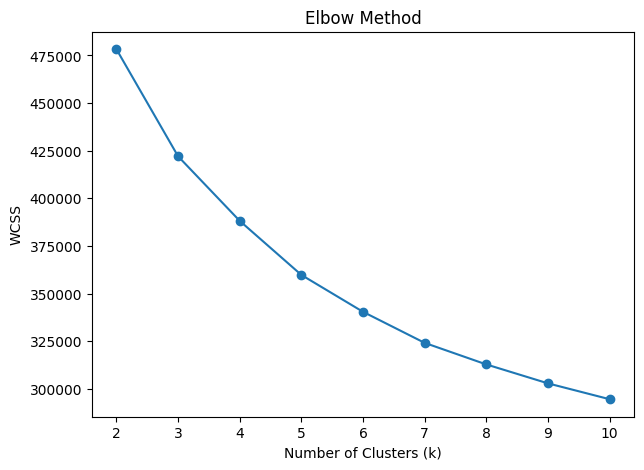

In [121]:
# ===============================================
# Elbow Method
# ===============================================

wcss = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [122]:
for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k = {k}, Silhouette Score = {score:.5f}")

k = 2, Silhouette Score = 0.18024
k = 3, Silhouette Score = 0.15468
k = 4, Silhouette Score = 0.14021
k = 5, Silhouette Score = 0.13444
k = 6, Silhouette Score = 0.13130
k = 7, Silhouette Score = 0.12249
k = 8, Silhouette Score = 0.12123
k = 9, Silhouette Score = 0.11577
k = 10, Silhouette Score = 0.11264


In [123]:
corr = df[features].corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

print(high_corr)

['Charge_Density']


In [133]:
# Final Model

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster Sizes
# ===============================================

print("\nCluster Counts\n")
print(df["Cluster"].value_counts())


Cluster Counts

Cluster
5    9391
3    7539
1    7404
0    7131
4    6611
8    6454
9    5193
2    4205
7    3777
6    2295
Name: count, dtype: int64


In [134]:
# Cluster Centers

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

print("\nCluster Centers\n")

print(cluster_centers.round(3))


Cluster Centers

   Isoelectric_Point  Hydrophobicity  Instability_Index  Aliphatic_Index  \
0              6.211           0.133             46.196           49.949   
1              5.838           0.135             44.917           60.688   
2              6.522           0.166             42.486           73.680   
3              6.109           0.162             44.435           60.584   
4              8.647           0.178             43.493           66.162   
5              8.354           0.148             44.898           59.870   
6              7.213           0.199             44.586           72.621   
7              5.941           0.101             47.373           48.920   
8              8.507           0.164             47.147           52.602   
9              8.679           0.128             49.237           48.092   

   Aromaticity  GRAVY  Flexibility  Mass_per_Residue  Charge_Density  \
0        0.165 -0.666        0.992           120.395           0.026   
1

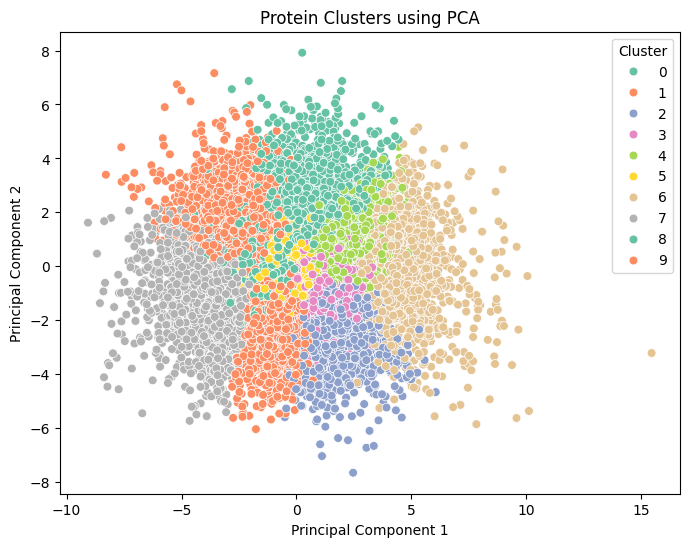

In [135]:
# PCA Visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="Set2",
    s=40
)

plt.title("Protein Clusters using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [136]:
# Cluster Summary

cluster_summary = (
    df.groupby("Cluster")[features]
      .mean()
      .round(5)
)

print("\nAverage Feature Values per Cluster\n")

print(cluster_summary)


Average Feature Values per Cluster

         Isoelectric_Point  Hydrophobicity  Instability_Index  \
Cluster                                                         
0                  6.21076         0.13340           46.19435   
1                  5.83826         0.13494           44.91532   
2                  6.52125         0.16638           42.48177   
3                  6.10841         0.16179           44.43503   
4                  8.64746         0.17793           43.50298   
5                  8.35366         0.14804           44.89638   
6                  7.21570         0.19882           44.57033   
7                  5.94301         0.10086           47.36499   
8                  8.50567         0.16411           47.13746   
9                  8.67998         0.12814           49.25580   

         Aliphatic_Index  Aromaticity    GRAVY  Flexibility  Mass_per_Residue  \
Cluster                                                                         
0               49.9

In [137]:
# Save Result

df.to_csv("Protein_Clusters.csv", index=False)

print("\nProtein_Clusters.csv saved successfully.")


Protein_Clusters.csv saved successfully.


In [138]:
from scipy.stats import zscore

features = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Basic_Acidic_Ratio"
]

z = np.abs(df[features].apply(zscore))

df_clean = df[(z < 3).all(axis=1)]

In [139]:
df_clean

,Protein_ID,Protein_Sequence,Molecular_Weight,Isoelectric_Point,Hydrophobicity,Total_Charge,Polar_Content,Apolar_Content,Sequence_Length,Protein_Class,...,Sequence_Length_Class,Hydrophobicity_Level,Charge_Class,Polar_Level,Hydrophobic_Content,Charge_Density,Mass_per_Residue,Hydrophobic_Polar_Ratio,Apolar_Polar_Ratio,Cluster
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptor,...,Very Long,Very Low,Positive,Moderate,Moderate,0.019139,118.025853,1.499288,2.226215,7
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Structural,...,Long,Moderate,Positive,Moderate,Moderate,0.016760,118.905425,1.822570,2.704459,3
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzyme,...,Medium,High,Highly Positive,Moderate,High,0.060403,115.811911,2.258013,3.257462,2
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transport,...,Short,Very High,Highly Positive,Moderate,Moderate,0.071429,120.328479,1.147732,1.666062,8
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Others,...,Long,High,Highly Positive,Moderate,Moderate,0.026596,120.434632,1.709680,2.419855,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,P59996,QGVLVHQCCLKVQYMWYGGPNFLGNKNSMMVHTYLQYMSMGSVPES...,17576.9275,8.833732,0.143333,12,0.253333,0.346667,150,Others,...,Long,Low,Highly Positive,Moderate,Moderate,0.080000,117.179517,1.104827,1.893989,9
59996,P59997,KNVVYWHMILLNNHWENWHRTMAESTMGMFPTYFSDHFDQKFLWSL...,14658.6439,6.765568,0.179167,7,0.166667,0.458333,120,Receptor,...,Medium,Very High,Highly Positive,Moderate,High,0.058333,122.155366,2.148711,3.148111,3
59997,P59998,CRLHHMHSGACDRQWDHHFNTDPPTLYKCSEAHYKKGLMSSNIVNM...,9412.4561,5.814709,0.086420,3,0.234568,0.296296,81,Transport,...,Short,Very Low,Positive,Moderate,Moderate,0.037037,116.203162,1.315229,1.893929,7
59998,P59999,DDRPTLVMTTSHFLRLDNYKWCHNHTWMLVPILTQIPSAQVHTRVN...,28956.5694,5.895420,0.162000,4,0.224000,0.420000,250,Structural,...,Very Long,High,Positive,Moderate,High,0.016000,115.826278,1.856314,2.409639,2


In [139]:
features = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Charge_Density",
    "Basic_Acidic_Ratio",
]

from sklearn.preprocessing import StandardScaler

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.10845355, -1.65002239, -0.3164404 , ...,  0.8033328 ,
        -0.72958182, -0.69641534],
       [-0.94428631,  0.03210601, -1.54917605, ...,  0.49435828,
        -0.78603752, -0.71231755],
       [-0.02175363,  0.78147073, -0.87213163, ..., -0.7297285 ,
         0.24965483,  0.20511745],
       ...,
       [-0.99823651, -2.34551651,  2.67974409, ...,  0.94446878,
        -0.30483669, -0.55329548],
       [-0.94248012,  0.44408639,  0.46477335, ..., -0.460357  ,
        -0.80406782, -0.66143049],
       [ 1.05781454, -0.70415543,  0.75802733, ...,  1.3635481 ,
         0.18294536, -0.03836689]], shape=(60000, 9))

In [140]:
from scipy.stats import zscore
import numpy as np

z = np.abs(zscore(df[features]))

df_clean = df[(z < 3).all(axis=1)]

X1 = df_clean[features]

X_scaled1 = StandardScaler().fit_transform(X1)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled1)

print(X_pca.shape)

(57025, 6)


In [141]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    print(f"k = {k}, Silhouette Score = {score:.5f}")

k = 2, Silhouette Score = 0.21175
k = 3, Silhouette Score = 0.19896
k = 4, Silhouette Score = 0.17413
k = 5, Silhouette Score = 0.15802
k = 6, Silhouette Score = 0.15513
k = 7, Silhouette Score = 0.15066


In [128]:
from sklearn.mixture import GaussianMixture

for k in range(2,8):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    print(f"k = {k}, Silhouette Score = {score:.5f}")

k = 2, Silhouette Score = 0.19671
k = 3, Silhouette Score = 0.16185
k = 4, Silhouette Score = 0.09553
k = 5, Silhouette Score = 0.06331
k = 6, Silhouette Score = 0.08618
k = 7, Silhouette Score = 0.06633


In [164]:
features1 = [
    "Polar_%",
    "Basic_Acidic_Ratio",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Isoelectric_Point"
]

from sklearn.preprocessing import StandardScaler

X11 = df[features1]

# Standardize
scaler = StandardScaler()
X_scaled11 = scaler.fit_transform(X11)
X_scaled11

array([[ 0.31436339, -0.69641534, -0.3164404 , ..., -0.74284864,
         0.8033328 , -1.10845355],
       [-0.29622832, -0.71231755, -1.54917605, ...,  0.39768376,
         0.49435828, -0.94428631],
       [-0.55539318,  0.20511745, -0.87213163, ...,  1.48269495,
        -0.7297285 , -0.02175363],
       ...,
       [ 1.02758188, -0.55329548,  2.67974409, ..., -0.96683144,
         0.94446878, -0.99823651],
       [ 0.71407416, -0.66143049,  0.46477335, ...,  1.46659192,
        -0.460357  , -0.94248012],
       [-0.33961367, -0.03836689,  0.75802733, ..., -0.12702117,
         1.3635481 ,  1.05781454]], shape=(60000, 8))

In [154]:
corr = df[features1].corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [column for column in upper.columns if any(upper[column] > 0.85)]

print(drop_cols)

[]


In [155]:
corr = df[features1].corr()

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ))

for item in high_corr:
    print(item)

In [165]:
# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca11 = pca.fit_transform(X_scaled11)

print("Shape after PCA:", X_pca11.shape)

Shape after PCA: (60000, 6)


In [167]:
X11 = df[features1]
print(X11.shape)

X_scaled11 = scaler.fit_transform(X11)
print(X_scaled11.shape)

pca = PCA(n_components=0.95, random_state=42)

X_pca11 = pca.fit_transform(X_scaled11)   # <-- Does the error happen here?

print(X_pca11.shape)

(60000, 8)
(60000, 8)
(60000, 6)


In [169]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca11)

    score = silhouette_score(
        X_pca11,
        labels,
        sample_size=10000,   # use a random sample
        random_state=42
    )

    print(f"k = {k}, Silhouette Score = {score:.5f}")

k = 2, Silhouette Score = 0.17031
k = 3, Silhouette Score = 0.16233
k = 4, Silhouette Score = 0.14390
k = 5, Silhouette Score = 0.13425
k = 6, Silhouette Score = 0.13193
k = 7, Silhouette Score = 0.12533


In [179]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features2 = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Charge_Density",
    "Basic_Acidic_Ratio",
]

classes = ["Enzyme", "Receptor", "Transport", "Structural", "Others"]

for protein_class in classes:

    print("\n" + "="*50)
    print(f"Protein Class: {protein_class}")
    print("="*50)

    temp = df[df["Protein_Class"] == protein_class].copy()

    X = temp[features2]

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    best_score = -1
    best_k = None
    best_labels = None

    for k in range(2, 8):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(X_pca)

        score = silhouette_score(
            X_pca,
            labels,
            sample_size=min(5000, len(X_pca)),
            random_state=42
        )

        print(f"k = {k}, Silhouette Score = {score:.5f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nBest k = {best_k}")
    print(f"Best Silhouette Score = {best_score:.5f}")

    # Store cluster labels only for this protein class
    temp["Cluster"] = best_labels

    print("\nCluster Counts")
    print(temp["Cluster"].value_counts())

    print("\nCluster Summary")
    print(
        temp.groupby("Cluster")[features2]
        .mean()
        .round(3)
    )


Protein Class: Enzyme
k = 2, Silhouette Score = 0.20793
k = 3, Silhouette Score = 0.19266
k = 4, Silhouette Score = 0.17303
k = 5, Silhouette Score = 0.15799
k = 6, Silhouette Score = 0.14832
k = 7, Silhouette Score = 0.14826

Best k = 2
Best Silhouette Score = 0.20793

Cluster Counts
Cluster
1    6072
0    5882
Name: count, dtype: int64

Cluster Summary
         Isoelectric_Point  Hydrophobicity  Instability_Index  \
Cluster                                                         
0                    8.281           0.166             44.872   
1                    6.266           0.135             45.659   

         Aliphatic_Index  Aromaticity  GRAVY  Flexibility  Charge_Density  \
Cluster                                                                     
0                 61.183        0.155 -0.421        0.988           0.077   
1                 55.921        0.145 -0.561        0.993           0.024   

         Basic_Acidic_Ratio  
Cluster                      
0           

In [205]:
all_clusters = []

for protein_class in classes:

    temp = df[df["Protein_Class"] == protein_class].copy()

    X = temp[features2]

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=0.95, random_state=42).fit_transform(X_scaled)

    model = KMeans(n_clusters=2, random_state=42, n_init=20)

    labels = model.fit_predict(X_pca)

    temp["Cluster"] = labels

    all_clusters.append(temp)

final_clusters = pd.concat(all_clusters, ignore_index=True)

final_clusters.to_csv("Protein_Classwise_Clusters.csv", index=False)

print(final_clusters.head())

  Protein_ID                                   Protein_Sequence  \
0     P00003  QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...   
1     P00008  PFGPKKPEQLNQIISQLICHPKQMVMFFDTKPPIIDEHAPSLMGPF...   
2     P00010  AVCYPYVEVRWEEAMINYWDREPAQYKSECKQVVLAVYALEYYRGP...   
3     P00023  YIACHYDLWKYFQQNEHLMKHHAEDYAWPQFTADVDVNEYTTFHQA...   
4     P00025  IPWRQRGDWKIKMIQVWNTDKLVPERVERPNIKRAARANAKADHNT...   

   Molecular_Weight  Isoelectric_Point  Hydrophobicity  Total_Charge  \
0        17255.9747           7.228237        0.171141             9   
1        14519.6919           6.210876        0.144531             3   
2        14188.0501           8.842306        0.192308             9   
3        10468.7083           6.218436        0.160714             5   
4         6960.9197          10.147082        0.152542             5   

   Polar_Content  Apolar_Content  Sequence_Length Protein_Class  ...  \
0       0.181208        0.422819              149        Enzyme  ...   
1       0.218750    

In [206]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

features2 = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Charge_Density",
    "Basic_Acidic_Ratio"
]

classes = ["Enzyme", "Receptor", "Transport", "Structural", "Others"]

for protein_class in classes:

    print("\n" + "="*50)
    print(f"Processing: {protein_class}")
    print("="*50)

    # Filter one protein class
    temp = df[df["Protein_Class"] == protein_class].copy()

    # Feature matrix
    X = temp[features2]

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # Find best k
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(2, 8):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        score = silhouette_score(
            X_pca,
            labels,
            sample_size=min(5000, len(X_pca)),
            random_state=42
        )

        print(f"k = {k}, Silhouette Score = {score:.5f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    # Add cluster labels
    temp["Cluster"] = best_labels

    print(f"\nBest k = {best_k}")
    print(f"Best Silhouette Score = {best_score:.5f}")

    # Save CSV
    file_name = f"{protein_class}_Clustered.csv"
    temp.to_csv(file_name, index=False)

    print(f"Saved: {file_name}")


Processing: Enzyme
k = 2, Silhouette Score = 0.20793
k = 3, Silhouette Score = 0.19266
k = 4, Silhouette Score = 0.17303
k = 5, Silhouette Score = 0.15799
k = 6, Silhouette Score = 0.14832
k = 7, Silhouette Score = 0.14826

Best k = 2
Best Silhouette Score = 0.20793
Saved: Enzyme_Clustered.csv

Processing: Receptor
k = 2, Silhouette Score = 0.20316
k = 3, Silhouette Score = 0.19509
k = 4, Silhouette Score = 0.17298
k = 5, Silhouette Score = 0.14935
k = 6, Silhouette Score = 0.14526
k = 7, Silhouette Score = 0.14284

Best k = 2
Best Silhouette Score = 0.20316
Saved: Receptor_Clustered.csv

Processing: Transport
k = 2, Silhouette Score = 0.20428
k = 3, Silhouette Score = 0.19254
k = 4, Silhouette Score = 0.17483
k = 5, Silhouette Score = 0.15962
k = 6, Silhouette Score = 0.14866
k = 7, Silhouette Score = 0.13595

Best k = 2
Best Silhouette Score = 0.20428
Saved: Transport_Clustered.csv

Processing: Structural
k = 2, Silhouette Score = 0.20163
k = 3, Silhouette Score = 0.19498
k = 4, Sil

In [184]:
print("Cluster" in df.columns)

False


In [196]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

features2 = [
    "Isoelectric_Point",
    "Hydrophobicity",
    "Instability_Index",
    "Aliphatic_Index",
    "Aromaticity",
    "GRAVY",
    "Flexibility",
    "Charge_Density",
    "Basic_Acidic_Ratio",
]

# Full dataset
X = df[features2]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_pca)

print(len(labels))      # Should print 60000
print(len(df))          # Should print 60000

# Assign cluster labels
df["Cluster1"] = labels

print(df[["Protein_ID", "Cluster1"]].head())

60000
60000
  Protein_ID  Cluster1
0     P00001         0
1     P00002         0
2     P00003         1
3     P00004         1
4     P00005         1


In [197]:
cluster_summary = (
    df.groupby("Cluster1")[features2]
      .mean()
      .round(3)
)

print(cluster_summary)

          Isoelectric_Point  Hydrophobicity  Instability_Index  \
Cluster1                                                         
0                     6.443           0.132             46.049   
1                     8.070           0.168             44.823   

          Aliphatic_Index  Aromaticity  GRAVY  Flexibility  Charge_Density  \
Cluster1                                                                     
0                  54.831        0.143 -0.596        0.994           0.028   
1                  62.217        0.157 -0.385        0.988           0.071   

          Basic_Acidic_Ratio  
Cluster1                      
0                      1.204  
1                      1.790  


In [198]:
pd.crosstab(
    df["Cluster1"],
    df["Protein_Class"]
)

Protein_Class,Enzyme,Others,Receptor,Structural,Transport
Cluster1,,,,,
0,5961,6079,5841,5942,6058
1,5993,6137,6009,6049,5931


In [199]:
pd.crosstab(
    df["Cluster1"],
    df["Protein_Class"],
    normalize="index"
) * 100

Protein_Class,Enzyme,Others,Receptor,Structural,Transport
Cluster1,,,,,
0,19.949132,20.344031,19.547539,19.885546,20.273753
1,19.897739,20.375842,19.950862,20.083668,19.691889


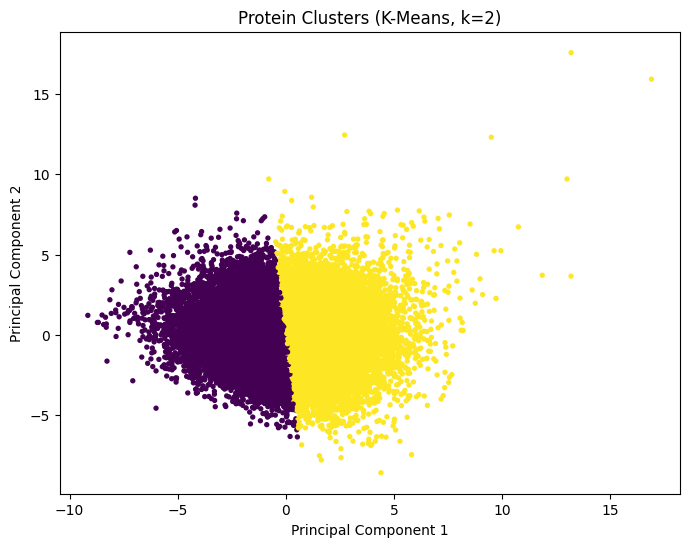

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster1"],
    cmap="viridis",
    s=8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Protein Clusters (K-Means, k=2)")

plt.show()

In [193]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X3 = df[features2]

scaler = StandardScaler()
X_scaled3 = scaler.fit_transform(X3)

pca = PCA(n_components=0.95, random_state=42)
X_pca3 = pca.fit_transform(X_scaled3)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_pca3)

# Save labels for all 60,000 proteins
df["Cluster2"] = labels

print(df["Cluster2"].value_counts())

Cluster2
1    17484
3    13203
0    12322
4     9075
2     7916
Name: count, dtype: int64


In [201]:
pd.crosstab(
    df["Cluster2"],
    df["Protein_Class"]
)

Protein_Class,Enzyme,Others,Receptor,Structural,Transport
Cluster2,,,,,
0,2442,2515,2472,2459,2434
1,3518,3561,3316,3518,3571
2,1526,1628,1600,1621,1541
3,2628,2710,2646,2608,2611
4,1840,1802,1816,1785,1832


In [202]:
pd.crosstab(
    df["Cluster2"],
    df["Protein_Class"],
    normalize="index"
) * 100

Protein_Class,Enzyme,Others,Receptor,Structural,Transport
Cluster2,,,,,
0,19.818211,20.410648,20.061678,19.956176,19.753287
1,20.121254,20.367193,18.965912,20.121254,20.424388
2,19.277413,20.565942,20.212228,20.477514,19.466902
3,19.904567,20.525638,20.040900,19.753086,19.775809
4,20.275482,19.856749,20.011019,19.669421,20.187328


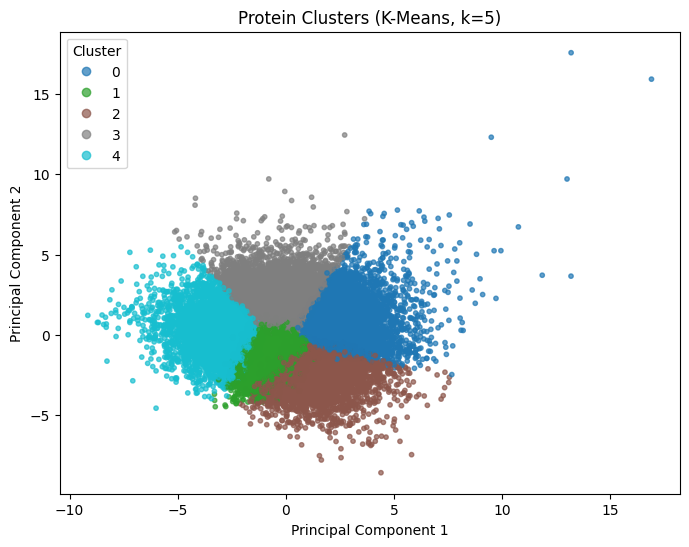

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster2"],
    cmap="tab10",      # Better for categorical clusters
    s=10,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Protein Clusters (K-Means, k=5)")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.show()

In [204]:
pd.crosstab(
    df["Cluster2"],
    df["Protein_Class"],
    normalize="index"
).round(3) * 100

Protein_Class,Enzyme,Others,Receptor,Structural,Transport
Cluster2,,,,,
0,19.8,20.4,20.1,20.0,19.8
1,20.1,20.4,19.0,20.1,20.4
2,19.3,20.6,20.2,20.5,19.5
3,19.9,20.5,20.0,19.8,19.8
4,20.3,19.9,20.0,19.7,20.2
